# TP-1 — TinyGPT: pretraining, decoding and Mixture of Experts

**Student: Christian Conchari**

You will pretrain a very small GPT (a transformer decoder) at the character level on
Shakespeare, then work on it in two directions.

## TinyGPT Architectures

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, we will begin with a dense model, equivalent and based off GPT-2, finally we will end up in a model that consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek-MoE/v2/v3/R1
- Qwen-MoE
- Mistral/Mixtral

**Part 1 — Inference.** The model gives you a probability distribution over the next
character. *Choosing* a character from it is a separate design decision, and it changes the
output far more than another epoch of training would.

**Part 2 — Architecture.** Replace the dense feed-forward block with a Mixture of Experts,
and measure what that buys and what it costs.

One model is trained once, at the top, and reused throughout.

## Tasks

**Part 1**
- Task I — implement `generateV2`: greedy, temperature, top-k and top-p.
- Task II — compare the decoding strategies and explain what each knob does.
- Task III — measure what the KV-cache actually buys you. Do not assume it wins.
- Task IV — read and explain the attention maps of your trained model.

**Part 2**
- Task V — implement top-k routing in `MoELayer.forward`.
- Task VI — train TinyGPT-MoE and compare it against the dense baseline.
- Task VII — measure expert utilization and diagnose routing collapse.
- Task VIII — implement [DeepSeekMoE](https://arxiv.org/pdf/2401.06066) and measure it.
- Task IX — your MoE is far slower per step than the dense model. Make it faster.

**Then**
- Task X — pretrain the *dense* model with a real subword GPT-2 tokenizer and compare properly. TP-2 and the
  TP-3 notebook depend on the checkpoint this produces.
- *Optional* — a load-balancing auxiliary loss.

## How to work on this

Every task a later cell depends on ships with a `check_*()` cell. Run it before moving on —
it costs seconds and catches the bugs that would otherwise show up as a flat loss curve half
an hour from now. All self-checks passing is the bar for submission.




In [1]:
import time
from typing import List, Optional

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader

from tinygpt import (
    CharDataset,
    CharTokenizer,
    GPTConfig,
    MoEArgs,
    count_parameters,
    describe,
    free,
    load_checkpoint,
    get_device,
    load_tinyshakespeare,
    plot_losses,
    resume,
    run_training,
    trim_kv_cache,
    visualize_attention,
)
from trainer import Trainer

torch.manual_seed(1337)

## Resuming after a kernel restart

This notebook trains four models and keeps them in scope, so a restart loses all of them
and every cell below fails with `NameError`. The weights and loss curves are on disk, so
you do not have to retrain — run the cell below and skip forward to wherever you were.

Leave it alone on a fresh run: it only restores what is already finished.


In [2]:
def resume_all():
    """
    Rebuild whichever models already have a finished checkpoint.

    Run the cells above first -- definitions are instant, only training is not -- then call
    this. It restores each model and its loss curve, and skips anything whose class or
    config is not in scope yet.
    """
    import os

    g = globals()
    specs = [
        ("model",     "./checkpoints/tp1_dense",    "history",     ("config",)),
        ("moe_model", "./checkpoints/tp1_moe",      "history_moe", ("moe_config",)),
        ("ds_model",  "./checkpoints/tp1_deepseek", "history_ds",  ("ds_config",)),
        ("sub_model", "./checkpoints/tp1_subword",  "sub_history", ("sub_config",)),
    ]

    made, skipped = [], []
    for name, path, hist, needs in specs:
        if not os.path.exists(os.path.join(path, "checkpoint_final.pt")):
            continue
        if any(n not in g for n in needs):
            skipped.append(f"{name} (needs {', '.join(needs)})")
            continue
        # reuse the object if the config cell has already built an untrained one
        m = g.get(name) or g["TinyGPT"](g[needs[0]]).to(g["device"])
        g[name], g[hist] = m, g["resume"](m, path, map_location=g["device"])
        made.append(name)

    print("restored:", ", ".join(made) if made else "nothing")
    if skipped:
        print("not yet:", "; ".join(skipped))


# resume_all()   # uncomment after a kernel restart


## Downloading the dataset

In [3]:
# Lower this if training is slow on your machine.
N_CHARS = 100_000

text = load_tinyshakespeare(N_CHARS)
print(text[:400])
print(f"...\n\n{len(text):,} characters")

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 
...

100,000 characters


## Character-level encoding

`CharTokenizer` maps every distinct character to an integer id. One character == one token.

In [4]:
tokenizer = CharTokenizer(text)
print(f"vocab_size = {tokenizer.vocab_size}")
print(repr("".join(tokenizer.chars)))

data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Train/validation split
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f"train {train_data.shape} | val {val_data.shape}")

vocab_size = 61
"\n !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz"
train torch.Size([90000]) | val torch.Size([10000])


## GPT configuration

`ff_class` lets Part 2 swap the feed-forward block for a MoE without touching the model code.

In [5]:
config = GPTConfig(vocab_size=tokenizer.vocab_size)
print(config)

GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=61, bias=True, tie_weights=True, ff_class=None, moe_args=None)


## Dataloaders

In [6]:
# Use 0 on macOS/MPS; a few workers help on CUDA.
NUM_WORKERS = 0

train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                          drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                        drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)

print(f"{len(train_loader)} train batches | {len(val_loader)} val batches")

1405 train batches | 155 val batches


# The architecture

The next three cells are the whole model. *Read them before running them*. The rest of the
course builds on this code, and TP-2 imports it from `tinygpt.py` instead of redefining it.

Three details are worth your attention, because they are the ones that are easiest to get
silently wrong:

1. Every `forward` returns the same 3-tuple `(out, kv_cache, weights)`. Deciding the return
   shape from *whether a cache was passed in* is a classic bug: the very first decoding step
   has no cache to pass, so the cache never turns on and `use_cache=True` becomes a no-op
   you never notice.
2. The causal mask and the positional embeddings are both offset by the cache length. With
   a cache the model sees one new token, but that token is not at position 0.
3. All heads are projected and attended in one batched matmul, not in a Python loop over
   per-head modules. At this size wall-clock is dominated by kernel launches rather than
   arithmetic, so a loop over `n_head` modules costs several times the rest of the step —
   which is the same effect you will measure, and fix, in Task IX.


In [7]:
class MultiHeadAttention(nn.Module):
    """
    Causal multi-head self-attention, batched across heads.

    All heads are projected in one matmul and attended in one batched matmul, rather than
    looping over an `AttentionHead` module per head. The loop version is easier to read but
    launches `n_head` separate small kernels per layer, and at this model size wall-clock is
    dominated by kernel launches rather than arithmetic -- so the loop cost several times
    the whole rest of the step.

    The attention is still written out by hand (scores, causal mask, softmax) rather than
    calling F.scaled_dot_product_attention, because the mask is the thing being taught and
    SDPA cannot return attention weights for the visualisation task.

    Every forward returns the same 3-tuple `(out, kv_cache, weights)`; the trailing entries
    are `None` when not requested.
    """

    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = args.n_head
        self.head_dim = args.n_embd // args.n_head

        # One projection for all heads: (B, T, C) -> (B, T, 3C), chunked K, Q, V.
        self.key_query_value = nn.Linear(args.n_embd, 3 * args.n_embd, bias=args.bias)
        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)

        self.attn_dropout = nn.Dropout(args.dropout)
        self.dropout = nn.Dropout(args.dropout)
        self.register_buffer(
            "tril", torch.tril(torch.ones(args.block_size, args.block_size))
        )

    def _split(self, t, B, T):
        """(B, T, C) -> (B, n_head, T, head_dim)"""
        return t.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        B, T, C = x.shape
        k, q, v = self.key_query_value(x).chunk(3, dim=-1)
        k, q, v = self._split(k, B, T), self._split(q, B, T), self._split(v, B, T)

        if kv_cache is not None:
            k_prev, v_prev = kv_cache.unbind(dim=0)      # (B, n_head, T_past, head_dim)
            k = torch.cat((k_prev, k), dim=2)
            v = torch.cat((v_prev, v), dim=2)

        new_cache = torch.stack((k, v)) if use_cache else None

        T_k = k.size(2)          # total keys attended to
        past = T_k - T           # how many of them came from the cache

        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)   # (B, n_head, T, T_k)
        # Rows are offset by `past` so the mask stays correct with a KV-cache:
        # query at absolute position `past + t` may see keys 0..past + t.
        wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.attn_dropout(wei)

        out = (wei @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.dropout(self.proj(out))

        # (n_head, B, T, T_k) -- the layout visualize_attention expects
        weights = wei.transpose(0, 1) if return_weights else None
        return out, new_cache, weights

In [8]:
class FeedForward(nn.Module):
    """Dense MLP: the module Part 2 replaces with a MoE."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Pre-norm transformer decoder block."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        attn_out, new_cache, weights = self.attn(
            self.ln1(x), kv_cache=kv_cache, use_cache=use_cache, return_weights=return_weights
        )
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, new_cache, weights

## TinyGPT

In [9]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        if config.tie_weights:
            self.head.weight = self.token_emb.weight

    def forward(self, idx, kv_cache=None, use_cache=False, return_weights=False):
        """
        Args:
            idx:            (B, T) token ids.
            kv_cache:       list of per-layer caches from a previous call, or None.
            use_cache:      return an updated KV-cache alongside the logits.
            return_weights: return per-layer attention maps alongside the logits.

        Returns:
            `logits` when both flags are False (this is what `Trainer` expects),
            otherwise a tuple `(logits[, kv_cache][, attn_weights])`.

        Note the flags drive the return shape -- NOT whether `kv_cache` happens
        to be None. Deriving it from the input is how a cache silently never
        turns on: the very first decoding step has no cache to pass in.
        """
        B, T = idx.shape
        past_len = kv_cache[0].shape[-2] if kv_cache is not None else 0
        assert past_len + T <= self.config.block_size, (
            f"sequence of {past_len + T} exceeds block_size={self.config.block_size}"
        )

        tok_emb = self.token_emb(idx)
        # Positions must continue from where the cache left off, otherwise every
        # cached step re-uses position 0.
        pos = torch.arange(past_len, past_len + T, device=idx.device)
        x = tok_emb + self.pos_emb(pos)[None, :, :]

        new_kv_cache = [] if use_cache else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_cache = kv_cache[i] if kv_cache is not None else None
            x, updated_kv, weights = block(
                x, kv_cache=layer_cache, use_cache=use_cache, return_weights=return_weights
            )
            if use_cache:
                new_kv_cache.append(updated_kv)
            if return_weights:
                all_weights.append(weights)

        logits = self.head(self.ln_f(x))

        if not use_cache and not return_weights:
            return logits
        out = [logits]
        if use_cache:
            out.append(new_kv_cache)
        if return_weights:
            out.append(all_weights)
        return tuple(out)

    @torch.no_grad()
    def resize_token_embeddings(self, new_vocab_size: int) -> None:
        """
        Grows the input embedding and the output head to `new_vocab_size`,
        preserving every pretrained row.

        Needed when fine-tuning adds special tokens (chat/instruction markers)
        that the pretraining vocabulary did not contain.
        """
        old_vocab, n_embd = self.token_emb.weight.shape
        if new_vocab_size == old_vocab:
            return
        assert new_vocab_size > old_vocab, "shrinking the vocabulary is not supported"

        device = self.token_emb.weight.device
        dtype = self.token_emb.weight.dtype

        new_emb = nn.Embedding(new_vocab_size, n_embd, device=device, dtype=dtype)
        new_emb.weight.normal_(mean=0.0, std=0.02)
        new_emb.weight[:old_vocab] = self.token_emb.weight
        self.token_emb = new_emb

        new_head = nn.Linear(n_embd, new_vocab_size, bias=False, device=device, dtype=dtype)
        new_head.weight.normal_(mean=0.0, std=0.02)
        new_head.weight[:old_vocab] = self.head.weight
        self.head = new_head

        self.config.vocab_size = new_vocab_size

## Baseline generation (inference)

This is the function you upgrade in Task I. It samples from the *full* softmax at temperature 1.0 — no truncation, no temperature control.

In [10]:
@torch.no_grad()
def generate(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    device: Optional[str] = None,
) -> str:
    """
    Baseline decoding: sample from the full softmax at temperature 1.0.

    This is the function TP-1 asks you to upgrade with greedy / temperature /
    top-k / top-p.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Never let the cache outgrow the context window.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

# Setup

In [11]:
device = get_device()
print(f"device: {device}")

model = TinyGPT(config).to(device)
describe(model, "TinyGPT (dense)")

# torch.compile traces the model and fuses kernels. It is a real speed-up on CUDA, it is
# unreliable on MPS (it crashes), and it buys little at this model size -- so it is enabled
# only where it helps.
#
# Note what it does to checkpoints: compiling wraps the module, so every state-dict key
# gains an "_orig_mod." prefix. That is why TP-2 and the serving notebook load weights
# through tinygpt.load_checkpoint, which strips it.
if device == "cuda":
    model = torch.compile(model)
    print("torch.compile enabled")


device: cuda
TinyGPT (dense): 106,048 parameters | 106,048 trainable (100.00%)
torch.compile enabled


In [12]:
EPOCHS = 2


def make_optimizer(params, lr: float = 1e-3):
    """
    8-bit Adam on CUDA, torch's AdamW everywhere else.

    bitsandbytes keeps optimizer state in 8 bits instead of 32, which roughly halves the
    memory Adam needs -- irrelevant at 800k parameters, and the reason you can fine-tune a
    7B model on one GPU.

    Every run in this notebook uses this, so the dense/MoE comparison never changes two
    things at once.
    """
    if device == "cuda":
        try:
            from bitsandbytes.optim import AdamW as bnbAdamW
            return bnbAdamW(params, lr=lr)
        except ImportError:
            print("bitsandbytes not installed (pip install bitsandbytes) -- using torch AdamW")
    return AdamW(params, lr=lr)


optimizer = make_optimizer(model.parameters())
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()


# Training

Roughly a minute per epoch on a GPU, longer on CPU. Reduce `N_CHARS` above if you need it
faster.

## What runs differently on CUDA

Three optimisations are enabled automatically when a CUDA device is present and skipped
otherwise. None of them changes the maths — they change what the hardware does with it.

| | what it does | why it is CUDA-only |
|---|---|---|
| **8-bit Adam** (`make_optimizer`) | optimizer state in 8 bits instead of 32, roughly halving Adam's memory | `bitsandbytes` has no Apple Silicon build |
| **`torch.compile`** | traces the model and fuses kernels | unreliable on MPS; it crashes |
| **bfloat16 autocast** (`run_training`) | half the activation memory, faster matmuls on tensor cores | MPS autocast is incomplete and `GradScaler` does not support that backend |

At this model size none of them matters much. They matter enormously at the scale where
you would actually use them, which is why they are here rather than left out: 8-bit Adam is
the difference between fine-tuning a 7B model on one GPU and not.

`run_training(..., use_amp=True)` forces mixed precision on if you want to see what it does
on your hardware.

## A note on memory

This notebook trains four models in one kernel and keeps them alive, because later cells
compare them. Neither CUDA nor MPS returns freed blocks to the OS on its own, and the MoE's
variable-shaped gathers fragment the allocator badly — so without help the kernel grows
until the machine starts swapping.

`free()` drops the cache, `run_training` calls it after every run, and the cells below call
it again after releasing a trainer. If you run out of memory anyway, restart the kernel and
lower `N_CHARS`.


mixed precision: on (bfloat16)


val_loss 2.24221: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 421.06it/s]


epoch 1/2 | train 2.1565 | val 2.0295


val_loss 2.17817: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 935.10it/s]


epoch 2/2 | train 2.0647 | val 1.9557


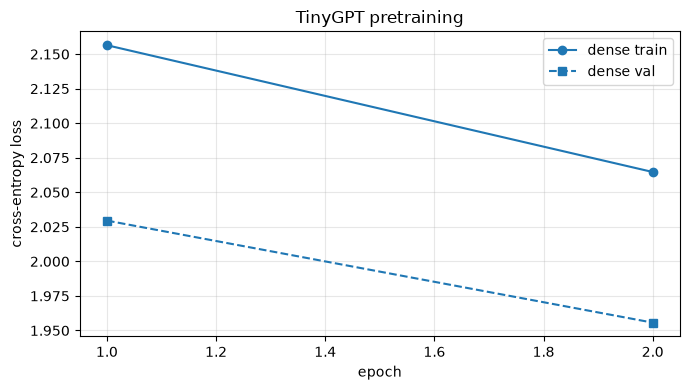

In [13]:
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints/tp1_dense",
    save_every_n=500,
)

history = run_training(trainer, epochs=EPOCHS)
plot_losses({"dense": history}, title="TinyGPT pretraining")

# The trainer pins the optimizer state; the model itself is still needed.
del trainer
free()

### Quick test

In [14]:
print(generate(model, tokenizer, "To be", max_new_tokens=300, use_cache=True))

To beart sprite
Nouce orve o' thethenontely y; m, Fore
Trint s ofutet arint lers godele then nos te cousplluntres llenoben tan by withed, ocanoudofave tra le suly nthesudlust'swort nasususab batrol, by gisutiyalofdindyouek,
t s uthowin, y ourscod we sthe mero me one se
s susucowe incedyeleree? aseet yout


# Task I — decoding strategies

The model gives you a probability distribution over the next character. *Choosing* a
character from that distribution is a separate design decision, and it changes the output
far more than another epoch of training would.

Implement `generateV2` below supporting:

- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

Apply the temperature first, then top-k, then top-p, then renormalise and sample.
`top_k=None` and `top_p=None` mean no truncation, and `do_sample=False` ignores every
other knob.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)
- [The Curious Case of Neural Text Degeneration (top-p)](https://arxiv.org/abs/1904.09751)


In [15]:
@torch.no_grad()
def generateV2(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 300,
    use_cache: bool = True,
    do_sample: bool = True,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    device: Optional[str] = None,
) -> str:
    """
    Args:
        do_sample:   False -> greedy (arg-max); every other knob is ignored.
        temperature: >0. Lower is more deterministic, higher is more random.
        top_k:       keep the k most likely tokens, or None for no truncation.
        top_p:       keep the smallest set whose cumulative probability >= p,
                     or None for no truncation.

    Returns:
        The prompt plus `max_new_tokens` generated characters.
    """
    assert not do_sample or temperature > 0, "temperature must be > 0 (use do_sample=False for greedy)"

    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # The cache must never outgrow the context window.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        logits = logits[:, -1, :]                                   # (B, V)

        if not do_sample:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)  # (B, 1)
        else:
            logits = logits / temperature

            if top_k is not None:
                k = min(top_k, logits.size(-1))
                top_vals, top_idx = torch.topk(logits, k, dim=-1)
                logits = torch.full_like(logits, float("-inf")).scatter(-1, top_idx, top_vals)

            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                # Use the mass *before* each token, so the token that crosses p is kept
                # and the most likely token always survives.
                mass_before = torch.cumsum(sorted_probs, dim=-1) - sorted_probs
                sorted_logits = sorted_logits.masked_fill(mass_before >= top_p, float("-inf"))
                logits = torch.full_like(logits, float("-inf")).scatter(-1, sorted_idx, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

## Self-check

Three properties that must hold if your implementation is right. Run this before
moving on — it catches most bugs.

In [16]:
def self_check():
    kw = dict(model=model, tokenizer=tokenizer, prompt="To be")

    # 1. greedy is deterministic
    a = generateV2(**kw, max_new_tokens=60, do_sample=False)
    b = generateV2(**kw, max_new_tokens=60, do_sample=False)
    assert a == b, "greedy decoding is not deterministic"

    # 2. top_k=1 collapses the distribution onto the arg-max, so it must equal greedy
    torch.manual_seed(0)
    c = generateV2(**kw, max_new_tokens=60, do_sample=True, top_k=1)
    assert c == a, "top_k=1 should reduce to greedy"

    # The next two look at a single step: over many steps a near-tie between the
    # top two logits will eventually break the exact match, which proves nothing.
    one = generateV2(**kw, max_new_tokens=1, do_sample=False)

    # 3. temperature -> 0 makes the softmax one-hot at the arg-max
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, temperature=1e-3) == one, \
        "temperature -> 0 should approach greedy"

    # 4. top_p -> 0 must keep exactly one token: the most likely one. This is the
    #    off-by-one from the hints -- a wrong comparison leaves an empty set here.
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, top_p=1e-9) == one, \
        "top_p -> 0 should keep the single most likely token"

    print("all checks passed")


self_check()

all checks passed


# Task II — compare the strategies

Run the grid below, read the samples, and answer the questions underneath.

In [17]:
PROMPT = "To be"

SETTINGS = [
    ("greedy",              dict(do_sample=False)),
    ("pure sampling (T=1)", dict(do_sample=True)),
    ("T=0.5",               dict(do_sample=True, temperature=0.5)),
    ("T=1.5",               dict(do_sample=True, temperature=1.5)),
    ("top_k=10",            dict(do_sample=True, top_k=10)),
    ("top_p=0.9",           dict(do_sample=True, top_p=0.9)),
    ("T=0.8 + top_p=0.9",   dict(do_sample=True, temperature=0.8, top_p=0.9)),
]

for name, kwargs in SETTINGS:
    torch.manual_seed(0)
    out = generateV2(model, tokenizer, PROMPT, max_new_tokens=200, **kwargs)
    print("=" * 70)
    print(f"### {name}")
    print(out)

### greedy
To be the the the the the the theateano tererererererereno the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th
### pure sampling (T=1)
To beche fortruied, to sa deff yofoublofusouthare? rinonrereinaco, he hy mum sthe, Mobe iomasyonorcce re oseala, matyolied f cowof ase rethin bymuce tede wousudyin edoficocereethe th tolichetare

Yamutofen
### T=0.5
To be he the thim to them denot meno ages lery, me wind the iususthe whe tre theno lobe wo sthe tonce the seathe methe tedofouthe tourer then the theele t theme theedoutest meere the tole hethe tre mutofen
### T=1.5
To beche.

SOLUFIA: ENI muneff yo'Thilofuslhinare? ririnrereifaco, he hyomum adeRa Mobehiomasy corkce  pe; malm, matyoliedliy, adatuse r trce bymuce elepristimbyin edoRPeocareefne'th bo
vellof
edrar?udoren
### top_k=10
To be he thim tied, to sa denat mange we
Aly, mend wirinthe iusus net hyours adethelo whis sthinot ce ble as

## Questions

Answer in this cell.

1. Greedy decoding degenerates in a very specific way. Describe what happens and
   explain *why* the arg-max policy produces it.
2. `T=1.5` and `T=0.5` fail in opposite directions. Name both failure modes.
3. Top-k and top-p both truncate the distribution. Give a concrete situation where
   a fixed `k` is the wrong choice and top-p adapts better. (Think about how peaked
   the distribution is after `Th` versus after a space.)
4. Which setting would you ship, and why?

---

1. Greedy gets stuck almost right away, it writes "the the the the...", then a short detour into "tererererer..." and back to "the the the" until the end. Greedy is just argmax(logits), so the same context always gives the same next character. The model only sees the last 32 characters, and once that window is full of "the the the " every step sees basically the same context it saw a few steps before, so argmax keeps returning the same cycle and the loop feeds itself. "the" is the most frequent word in the text, so it wins the argmax in a lot of contexts and the loop starts early, and since there's no randomness there's nothing to get it out.

2. A low T sharpens the softmax toward the argmax and a high T flattens it toward uniform, so they fail in opposite ways. With `T=0.5` the likely characters get even more probability and it behaves like a softer greedy, low diversity and the same chunks over and over ("the thim to them", "the tre theno", "theme theedoutest"). With `T=1.5` characters that should have near-zero probability get sampled all the time and the output turns into noise, like "SOLUFIA: ENI muneff", "corkce", "Peocareefne'th", capitals in the middle of words like "adeRa".

3. After "Th" the distribution is very peaked, the next character is almost always a vowel ("The", "Thou", "That", "This"), maybe 3 or 4 characters already cover 90%+ of the mass. A fixed `top_k=10` still keeps 10 candidates, so around 6 near-impossible characters stay in the pool and there's a real risk of sampling something like a "k" after "Th", in a context where the model was practically certain. After a space it's the opposite, almost any letter can start the next word and the mass is spread over many characters, so the same `top_k=10` can cut letters that were perfectly reasonable. `top_k` doesn't care how peaked the distribution is, it always keeps k, while top_p thresholds on cumulative probability, so it keeps a few vowels after "Th" and many letters after a space.

4. I would ship `T=0.8 + top_p=0.9`. It doesn't loop like greedy or `T=0.5` and it doesn't turn into noise like `T=1.5`. Most words are still invented, but short real ones show up ("he", "to", "mend", "net"), there are no long repeated chunks, and it even breaks the line and starts the next one with a capital ("Aly, mend"). The temperature below 1 sharpens the distribution first, so less low-probability stuff makes it into the nucleus, and then `top_p` cuts what's left of the tail. `top_p` alone (`T=1`) keeps more of that tail, and `T=0.5` alone sharpens too much. None of these outputs is real English with a model this small, so for me it was more about picking the one that fails the least.

# Task III — what does the KV-cache actually buy you?

### Theory
Without a cache, generating token *n* re-runs attention over all *n* previous
tokens. With a cache, the keys and values of those tokens are reused and only the
new token is projected. Asymptotically that turns O(N²) generation into O(N).

### Task
**Measure whether the theory actually holds here, and do not assume the
cache wins** — report the number you get, whatever it is, and then explain it.

Length: 50
Cache Time: 0.0233s
No Cache Time: 0.0224s
Speed-up: 0.96x

Length: 100
Cache Time: 0.0462s
No Cache Time: 0.0442s
Speed-up: 0.96x

Length: 200
Cache Time: 0.0928s
No Cache Time: 0.0888s
Speed-up: 0.96x

Length: 400
Cache Time: 0.1907s
No Cache Time: 0.1751s
Speed-up: 0.92x



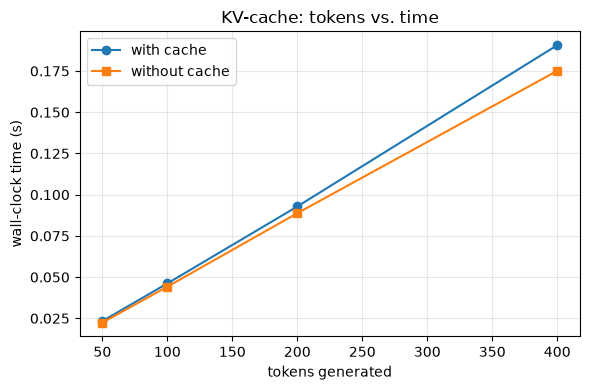

In [18]:
def benchmark_cache(lengths=(50, 100, 200, 400), repeats: int = 3):
    """
    For each length, time generation with use_cache=True and use_cache=False and
    print the speed-up. Plot tokens vs. wall-clock time for both.
    """
    # torch.compile can run out of graphs and fall back to eager for just one of the branches
    # (that gave me a fake 2x the first time), so both branches are timed on the eager model.
    eager_model = getattr(model, "_orig_mod", model)

    def timed(length, use_cache):
        # Greedy, so both runs produce the same text and only the cache differs.
        # The minimum over repeats filters out one-off scheduler noise.
        times = []
        for _ in range(repeats):
            start_time = time.perf_counter()
            # generateV2 ends with .tolist(), which waits for the GPU, so the clock is accurate.
            generateV2(eager_model, tokenizer, "To be", max_new_tokens=length,
                       use_cache=use_cache, do_sample=False)
            times.append(time.perf_counter() - start_time)
        return min(times)

    cache_times, no_cache_times = [], []
    for length in lengths:
        cache_time = timed(length, use_cache=True)
        no_cache_time = timed(length, use_cache=False)
        cache_times.append(cache_time)
        no_cache_times.append(no_cache_time)

        speed_up = no_cache_time / cache_time
        print("=" * 70)
        print(f"Length: {length}")
        print(f"Cache Time: {cache_time:.4f}s")
        print(f"No Cache Time: {no_cache_time:.4f}s")
        print(f"Speed-up: {speed_up:.2f}x")
        print("")

    plt.figure(figsize=(6, 4))
    plt.plot(lengths, cache_times, marker="o", label="with cache")
    plt.plot(lengths, no_cache_times, marker="s", label="without cache")
    plt.xlabel("tokens generated")
    plt.ylabel("wall-clock time (s)")
    plt.title("KV-cache: tokens vs. time")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


benchmark_cache()

In [19]:
from torch.profiler import ProfilerActivity, profile


def profile_decoding_step(n_tokens: int = 200):
    """Per decoding step: PyTorch op calls on the CPU (nested aten:: calls included), GPU kernels launched, and GPU busy time."""
    if device != "cuda":
        print("needs a CUDA device")
        return

    eager_model = getattr(model, "_orig_mod", model)
    for use_cache in (True, False):
        with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
            generateV2(eager_model, tokenizer, "To be", max_new_tokens=n_tokens,
                       use_cache=use_cache, do_sample=False)
        events = prof.key_averages()
        ops = sum(e.count for e in events if e.key.startswith("aten::")) / n_tokens
        gpu_events = [e for e in events if e.device_type.name == "CUDA"]
        kernels = sum(e.count for e in gpu_events) / n_tokens
        busy_us = sum(e.self_device_time_total for e in gpu_events) / n_tokens

        print(f"use_cache={use_cache!s:5}: {ops:4.0f} PyTorch ops/step | {kernels:3.0f} GPU kernels/step | "
              f"GPU busy {busy_us:5.1f} us/step")


profile_decoding_step()

USDT:2026-10-01 19:51:07 128996:128996 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-10-01 19:51:07 128996:128996 SyncActivityProfilerHandler.cpp:46] profiler_stop


use_cache=True :  293 PyTorch ops/step |  46 GPU kernels/step | GPU busy  65.1 us/step


USDT:2026-10-01 19:51:09 128996:128996 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-10-01 19:51:10 128996:128996 SyncActivityProfilerHandler.cpp:46] profiler_stop


use_cache=False:  288 PyTorch ops/step |  50 GPU kernels/step | GPU busy 101.6 us/step


Question 4 is about where cached and uncached decoding stop agreeing. This cell generates the
same greedy text both ways and finds the first character where they differ.

In [20]:
eager_model = getattr(model, "_orig_mod", model)
cached = generateV2(eager_model, tokenizer, "To be", max_new_tokens=100, use_cache=True, do_sample=False)
uncached = generateV2(eager_model, tokenizer, "To be", max_new_tokens=100, use_cache=False, do_sample=False)
first_difference = next((i for i, (a, b) in enumerate(zip(cached, uncached)) if a != b), None)
print(f"block_size = {model.config.block_size}; the two outputs first differ at index {first_difference}")

block_size = 32; the two outputs first differ at index 33


## Questions

1. Did the cache make generation faster? Report your numbers. If it did not,
   explain where the time actually goes: count the kernel launches and the tensor
   allocations this implementation performs per decoding step, and weigh them against the
   arithmetic the cache saves.
2. Asymptotically the cache is a clear win. Name the specific properties of *this*
   implementation and *this* model size that hide that win, and describe a setting
   (model size, sequence length, attention implementation) where it would clearly show up.
3. What does the cache cost you in memory? Give the formula in terms of `n_layer`,
   `n_head`, `head_dim`, batch size and sequence length, and evaluate it for this model.
4. Cached and uncached decoding produce identical text while the sequence fits in
   the context window, and diverge after that. Why?

---

1. No. On the GPU the cache made generation slightly **slower** at every length (0.92x to 0.96x). Both branches run the same uncompiled model (see the comment in `benchmark_cache`):

| tokens | with cache | without cache | speed-up |
|---|---|---|---|
| 50 | 0.0233 s | 0.0224 s | 0.96x |
| 100 | 0.0462 s | 0.0442 s | 0.96x |
| 200 | 0.0928 s | 0.0888 s | 0.96x |
| 400 | 0.1907 s | 0.1751 s | 0.92x |

This took a few tries to measure properly. On CPU (an earlier version of this notebook, not shown here) the cache looked a bit faster, but those runs were noisy. On the GPU the first run showed around 2x, but that turned out to be an artifact. `torch.compile` had already used up its graph limit, so the uncached branch was silently running eager while the cached one was still compiled. Timing both branches on the eager model gave the numbers above, so I used the profiler to see where a step actually goes (`profile_decoding_step`, plus the 400-token run for the wall-clock time):

| | PyTorch op calls (incl. nested) | GPU kernels | GPU busy | wall-clock |
|---|---|---|---|---|
| with cache | 293 | 46 | 65 µs | 477 µs |
| without cache | 288 | 50 | 102 µs | 438 µs |

The cache does save arithmetic, the GPU works 65 µs per step instead of 102 µs and launches 4 fewer kernels. But a step takes about 460 µs, so the GPU is busy less than a quarter of the time, the rest is the CPU running the Python loop and dispatching PyTorch ops (~290 op calls per step, counting the ones nested inside others like `linear` → `addmm`). The kernels run asynchronously while the CPU keeps dispatching, so making them shorter doesn't make the step shorter. And the cache adds CPU work on top. In every layer it does an `unbind`, two `torch.cat` and a `torch.stack`, 3 new tensors per layer (6 per step) that copy the whole past. So the cached branch actually dispatches more ops, and ends up slightly slower.

2. Mostly the size of everything. The model is tiny (`n_embd=64`, `head_dim=16`, `n_layer=2`) and a whole step is ~100 µs of GPU work, less than what it costs the CPU to launch it, so saving part of that arithmetic barely matters. The context is only 32 tokens. With `idx[:, -block_size:]` the uncached branch never processes more than 32 tokens per step, so both branches are linear in N and the O(N²) argument, which assumes a context that keeps growing, doesn't apply. And the implementation pays a fixed cost per token anyway, with eager execution in a Python loop with batch size 1, attention written by hand as separate ops, and a cache that is rebuilt with `cat`/`stack` every step instead of being written into a preallocated buffer.

    The win would show up with a big model and a long context (thousands of dimensions and thousands of tokens), where an uncached step has to recompute K and V for the whole prefix in every layer and the GPU arithmetic becomes the bottleneck. A fused attention (SDPA or FlashAttention), a preallocated or paged cache, and CUDA graphs or `torch.compile` to cut the launch cost would make it even clearer, and the speed-up would grow with the sequence length.

3. The cache stores K and V for every layer, each with shape `(B, n_head, T, head_dim)` (stacked into one tensor of shape `(2, B, n_head, T, head_dim)` per layer, the 2 being K and V). Its size is:

    $$\text{memory} = 2 \cdot n_{layer} \cdot B \cdot n_{head} \cdot T \cdot \text{head\_dim} \cdot \text{bytes}$$

    Since $n_{head} \cdot \text{head\_dim} = n_{embd}$, that's the same as $2 \cdot n_{layer} \cdot B \cdot T \cdot n_{embd} \cdot \text{bytes}$, linear in sequence length and batch size, with `bytes` = 4 for `float32` and 2 for `bfloat16`/`float16`.

    For this model (`n_layer=2`, `n_head=4`, `head_dim=16`, `float32`), with `B=1` and `T=block_size=32`:

    $$2 \cdot 2 \cdot 1 \cdot 4 \cdot 32 \cdot 16 \cdot 4 = 32{,}768 \text{ bytes} = 32 \text{ KiB} \quad (\approx 1 \text{ KiB per token})$$

    The weights take about $106{,}048 \cdot 4 \approx 415$ KiB, so here the cache is negligible, with `B=64` it would be 2 MiB, and half precision halves it. In a large model with a long context it's the other way around, the cache can be bigger than the weights and becomes the main memory cost of decoding.

4. While the sequence fits in the window both paths compute the same thing. Every token's K and V are computed once, with the position and context they'll always have, so reading them from the cache is the same as recomputing them. In the cell above (greedy, prompt `"To be"`) the outputs match for 33 characters and first differ at index 33, right when the model has to predict from more than `block_size=32` tokens.

    After that they stop being equivalent. Without the cache, `idx[:, -block_size:]` slides the window and everything is recomputed, so the last 32 tokens get positions 0 to 31 again and every layer only sees that window, which is the situation the model saw in training. With the cache, `trim_kv_cache` just drops the oldest entries and the rest aren't recomputed, so they keep the positions they had when they came in, while the new token gets position 31. In layer 1 a cached K/V only depends on its token and that old position, but in layer 2 it was also computed from a layer-1 output that attended to tokens that are no longer in the window. With learned absolute position embeddings (`pos_emb`) that means the cached path works with stale K/V, and its predictions drift away from the uncached ones.

# Task IV — visualizing attention

A GPT completes text. Let us look at what the heads of your trained model
actually attend to.

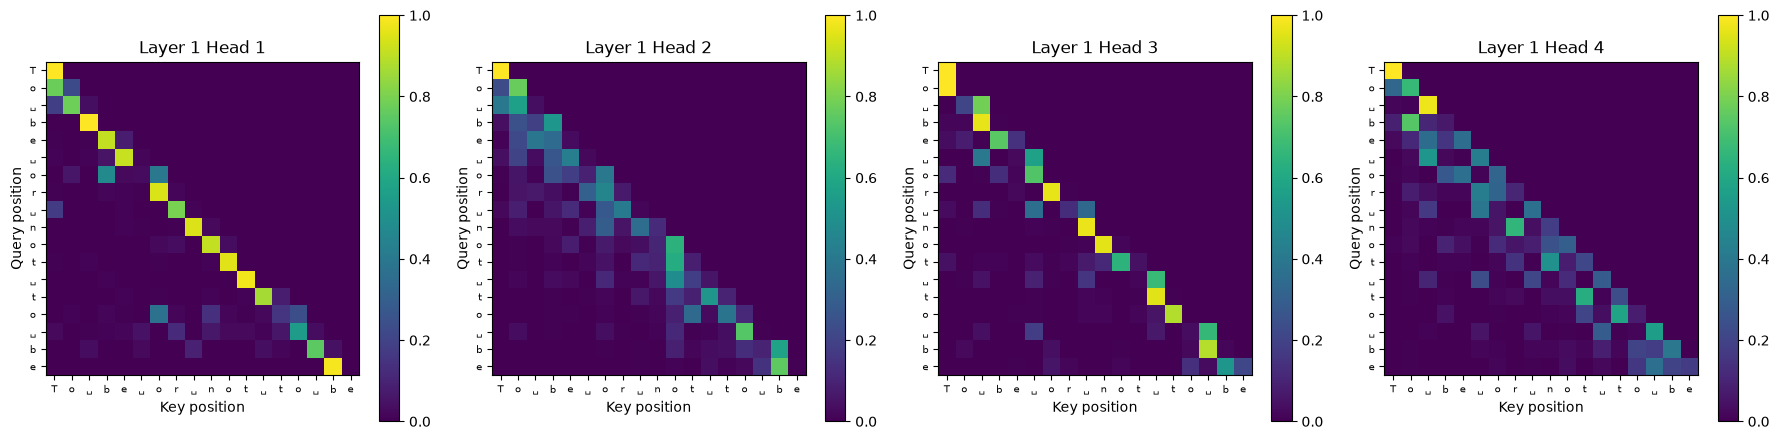

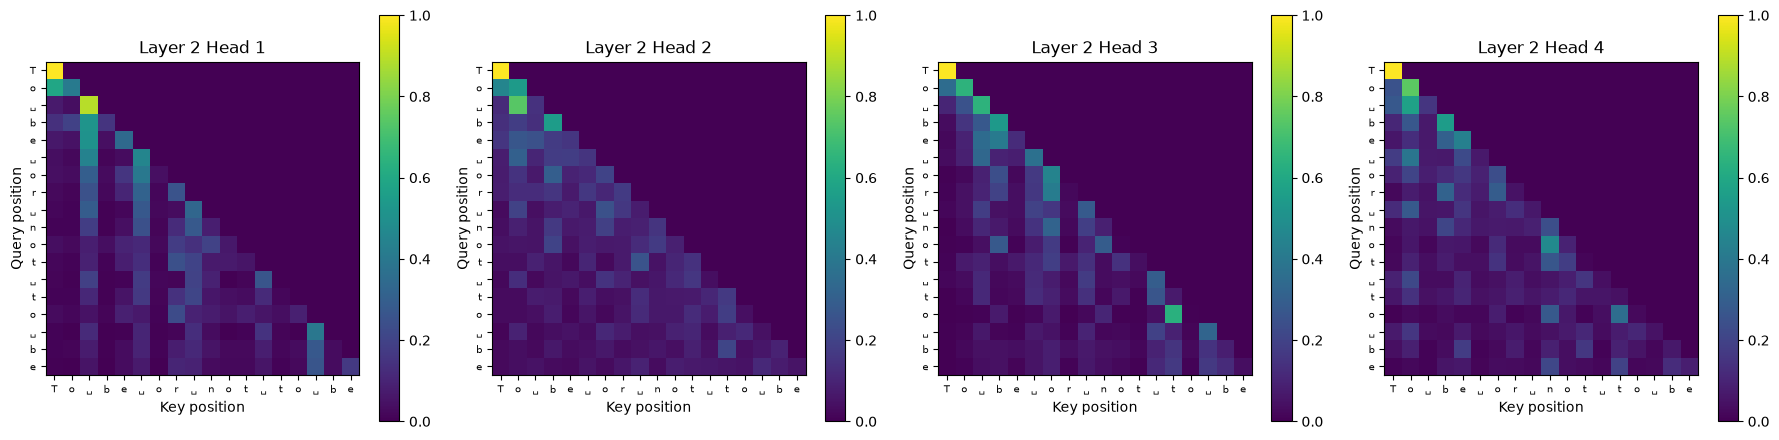

In [21]:
visualize_attention(model, tokenizer, "To be or not to be")

In [22]:
@torch.no_grad()
def attention_stats(model, tokenizer, prompt: str):
    """
    Per head, averaged over query positions 1..T-1 (position 0 can only see itself):
    attention mass on the previous character, normalized entropy (1 = uniform over the
    visible keys), and attention mass on spaces.
    """
    model.eval()
    dev = next(model.parameters()).device
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=dev)[None, :]
    _, all_weights = model(idx, return_weights=True)

    T = idx.shape[1]
    is_space = (idx[0] == tokenizer.stoi[" "]).float()
    n_visible = torch.arange(2, T + 1, device=dev).float()
    visible_spaces = torch.cumsum(is_space, dim=0)[1:]
    uniform_space_mass = (visible_spaces / n_visible).mean()

    print(f"{'head':<16}{'prev char':>10}{'entropy':>9}{'spaces':>8}")
    for layer, layer_weights in enumerate(all_weights):
        for head, attn in enumerate(layer_weights[:, 0].float()):
            rows = attn[1:]                                   # query t is row t-1
            prev = rows.diagonal().mean()
            # entropy of each row divided by its maximum, log(number of visible keys)
            entropy = (-(rows * rows.clamp_min(1e-12).log()).sum(-1) / n_visible.log()).mean()
            spaces = (rows * is_space).sum(-1).mean()
            print(f"Layer {layer + 1} Head {head + 1:<4}{prev:>10.2f}{entropy:>9.2f}{spaces:>8.2f}")
    print(f"\nmass on spaces if attention were uniform: {uniform_space_mass:.2f}")


attention_stats(model, tokenizer, "To be or not to be")

head             prev char  entropy  spaces
Layer 1 Head 1         0.78     0.30    0.24
Layer 1 Head 2         0.38     0.63    0.17
Layer 1 Head 3         0.63     0.31    0.55
Layer 1 Head 4         0.13     0.59    0.38
Layer 2 Head 1         0.16     0.77    0.60
Layer 2 Head 2         0.18     0.93    0.23
Layer 2 Head 3         0.22     0.81    0.42
Layer 2 Head 4         0.21     0.87    0.12

mass on spaces if attention were uniform: 0.27


## Questions

1. Every map is lower-triangular. Which line of `AttentionHead.forward` causes that,
   and what would break if you removed it?
2. Find one head that attends mostly to the immediately previous character and one
   that spreads its mass more widely. What is each one plausibly doing?

---

1. The causal mask, this line in `MultiHeadAttention.forward`:

    ```python
    wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
    ```

    It puts `-inf` on the scores of future keys, so after the softmax they get weight 0 and each query only sees itself and what comes before, that's the lower triangle in every map. Without it each position could look ahead, including the very character it has to predict (the target `y` is `x` shifted by one), so the model would just learn to copy, with a training loss close to zero without learning anything useful, and at generation time there's no future to copy, so the output would be garbage.

2. Looking at the maps, Layer 1 Head 1 is the clearest one, a bright line right below the diagonal, so almost every character looks at the one just before it. Layer 2 Head 1 has vertical stripes under the space characters, and Layer 2 Head 2 has no clear pattern at all, just a faint spread over the whole past. To check what I was seeing I computed a few numbers per head with `attention_stats` (prompt `"To be or not to be"`, averaged over query positions 1 to 17, uniform attention would put 0.27 of the mass on spaces):

    | Head | Mass on previous character | Normalized entropy (1 = uniform) | Mass on spaces |
    |---|---|---|---|
    | Layer 1 Head 1 | **0.78** | 0.30 | 0.24 |
    | Layer 2 Head 1 | 0.16 | 0.77 | **0.60** |
    | Layer 2 Head 2 | 0.18 | **0.93** | 0.23 |

    Layer 1 Head 1 puts 78% of its attention on the previous character, my guess is that it captures bigram statistics, like what usually comes after a `T` or a `t`. Layer 2 Head 2 is the spread one, entropy 0.93, almost uniform, so it probably works as a summary of the recent context (which word or line we're in) more than tracking a position. Layer 2 Head 1 I didn't expect. It sends 60% of its attention to spaces, more than twice the 27% it would get by chance, so it looks like it keeps track of where words start and end. It's only one prompt, though.

---

# Part 2 — Architecture

Part 1 changed how you *sample* from a trained model. Part 2 changes the model itself.

You will replace the dense feed-forward block with a Mixture of Experts — the idea
behind Mixtral, DeepSeek and Qwen-MoE — and compare it against the model you just trained.
No retraining of the baseline: the `model` and `history` from Part 1 are the comparison.

In a dense transformer every token goes through the *same* feed-forward network. A MoE
replaces that single FFN with `E` experts and a small gate that picks `k` of them
per token. Total parameters grow with `E`; the parameters *used* for any given token grow
only with `k`. You buy capacity without paying the matching compute.

The costs are real too, and you will measure them: the gate can collapse onto a few experts
and starve the rest, routing is discrete so gradients only reach the experts that were
selected, and a naive implementation is *slower* than the dense one at this scale.

### References
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088)
- [Outrageously Large Neural Networks (sparsely-gated MoE)](https://arxiv.org/abs/1701.06538)
- [Switch Transformers](https://arxiv.org/abs/2101.03961)
- `Clase_IV_MoEs.pdf`


In [23]:
def build_trainer(model, save_dir, lr=1e-3):
    """Same optimizer, scheduler and loss for every run, so only the architecture changes."""
    optimizer = make_optimizer(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
    return Trainer(
        model=model,
        train_data_loader=train_loader,
        test_data_loader=val_loader,
        loss_fn=torch.nn.CrossEntropyLoss(),
        gradient_accumulation_steps=1,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        save_dir=save_dir,
        save_every_n=500,
    )

## The building blocks

Two pieces, both given.

An expert is an FFN: the same `Linear -> ReLU -> Linear -> Dropout` stack the dense model
uses. Nothing exotic — the interesting part is who gets routed to it.

The gate scores every expert for every token, mapping `(B, T, n_embd)` to
`(B, T, num_experts)`. A single `nn.Linear`, no bias, no activation; the softmax happens
later, over the top-k scores only.

`Expert` takes its hidden width from `config.moe_args.expert_hidden_mult` rather than
hard-coding 4x. You will need that in Task VIII.


In [24]:
class Expert(nn.Module):
    """
    A single expert MLP inside a MoE layer.

    The hidden width comes from moe_args.expert_hidden_mult (4.0 is standard), so that
    fine-grained segmentation can shrink each expert without touching this class.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        hidden = int(config.moe_args.expert_hidden_mult * config.n_embd)
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, hidden),
            nn.ReLU(),
            nn.Linear(hidden, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Gate(nn.Module):
    """
    Router: scores each expert for each token. Returns raw logits, not probabilities.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe_args.num_experts, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


# Task V — top-k routing

This is the core of the assignment. `MoELayer.forward` takes `x` of shape
`(B, T, n_embd)` and returns the same shape.

The gate scores every expert for every token; you keep the top `k`, softmax over just
those, run each selected expert, and combine its output weighted by the gate. Routing is
per token, not per sequence — so flatten `(B, T, C)` to `(N, C)` before you route.

Two things to get right, because both fail quietly:

- The softmax goes *after* the top-k, over the selected experts only. Normalising before
  truncating leaves per-token weights that no longer sum to 1.
- Everything must stay differentiable, or the gate never learns.

Before returning, store the routing decision on the module —
`self.last_indices = indices.detach()` and
`self.last_gate_probs = F.softmax(logits, dim=-1).detach()` — Task VII reads these.


In [25]:
class MoELayer(nn.Module):
    """
    Sparsely-gated Mixture of Experts feed-forward layer.
    """

    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None
        self.last_gate_probs_grad = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        # Routing is per token, not per sequence.
        x_flat = x.reshape(-1, C)

        logits = self.gate(x_flat)

        # Softmax over the k selected experts only, so each token's weights sum to 1.
        top_vals, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        weights = F.softmax(top_vals, dim=-1)

        out = torch.zeros_like(x_flat)
        for e, expert in enumerate(self.experts):
            token_idx, slot_idx = torch.where(indices == e)
            if token_idx.numel() == 0:
                continue
            expert_out = expert(x_flat[token_idx])
            w = weights[token_idx, slot_idx].unsqueeze(-1)
            # out-of-place index_add, so there is no in-place update for autograd to track
            out = out.index_add(0, token_idx, (expert_out * w).to(out.dtype))

        self.last_indices = indices.detach()
        probs = F.softmax(logits, dim=-1)
        self.last_gate_probs = probs.detach()
        # Same values with gradient: the optional load-balancing loss needs them.
        self.last_gate_probs_grad = probs

        return out.view(B, T, C)


class MoEFFN(nn.Module):
    """
    Drop-in replacement for FeedForward. Assigned to config.ff_class so that
    Block picks it up without any change to the model code.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.moe_args is not None, "config.moe_args must be set to use MoEFFN"
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe_args.num_experts)],
            gate=Gate(config),
            moe_args=config.moe_args,
        )

    def forward(self, x):
        return self.moe(x)

## Self-check

Run this before training. It costs seconds and catches the routing bugs that would otherwise show up as a flat loss curve half an hour from now.

In [26]:
def check_moe():
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    layer = MoELayer([Expert(cfg) for _ in range(4)], Gate(cfg), cfg.moe_args)
    layer.eval()
    x = torch.randn(2, 5, 32)

    # 1. shape is preserved
    out = layer(x)
    assert out.shape == x.shape, f"{out.shape} != {x.shape}"

    # 2. gradients reach both the experts and the gate
    out.sum().backward()
    assert layer.gate.proj.weight.grad is not None, "the gate receives no gradient"
    assert any(p.grad is not None and p.grad.abs().sum() > 0
               for p in layer.experts.parameters()), "no expert receives gradient"

    # 3. with k=1 the output must equal the selected expert, untouched
    cfg1 = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                     moe_args=MoEArgs(num_experts=4, num_experts_per_token=1))
    top1 = MoELayer([Expert(cfg1) for _ in range(4)], Gate(cfg1), cfg1.moe_args)
    top1.eval()
    with torch.no_grad():
        y = top1(x)
        choice = top1.gate(x).argmax(dim=-1)          # (B, T)
        expected = torch.stack([
            torch.stack([top1.experts[int(choice[b, t])](x[b, t]) for t in range(x.shape[1])])
            for b in range(x.shape[0])
        ])
    err = (y - expected).abs().max().item()
    assert err < 1e-5, f"top-1 routing mismatch: {err}"

    # 4. routing must be per token, not per sequence
    assert top1.last_indices is not None, "store last_indices (see Task V)"
    assert top1.last_indices.shape[0] == x.shape[0] * x.shape[1]

    print("all checks passed")


check_moe()

all checks passed


# Task VI — train TinyGPT-MoE

`Block` reads `config.ff_class`, so turning TinyGPT into a MoE is a configuration
change, not a code change.

In [27]:
moe_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=MoEFFN,
    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2),
)

moe_model = TinyGPT(moe_config).to(device)
if device == "cuda":
    moe_model = torch.compile(moe_model)

describe(model, "TinyGPT (dense)")
describe(moe_model, f"TinyGPT-MoE (E={moe_config.moe_args.num_experts}, k={moe_config.moe_args.num_experts_per_token})")

dense_total, _ = count_parameters(model)
moe_total, _ = count_parameters(moe_model)
print(f"\nparameter growth: {moe_total / dense_total:.2f}x")

TinyGPT (dense): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT-MoE (E=4, k=2): 305,088 parameters | 305,088 trainable (100.00%)

parameter growth: 2.88x


mixed precision: on (bfloat16)


val_loss 2.20303: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 176.32it/s]


epoch 1/2 | train 2.0569 | val 1.9383


val_loss 2.14622: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 265.09it/s]


epoch 2/2 | train 1.9921 | val 1.8653


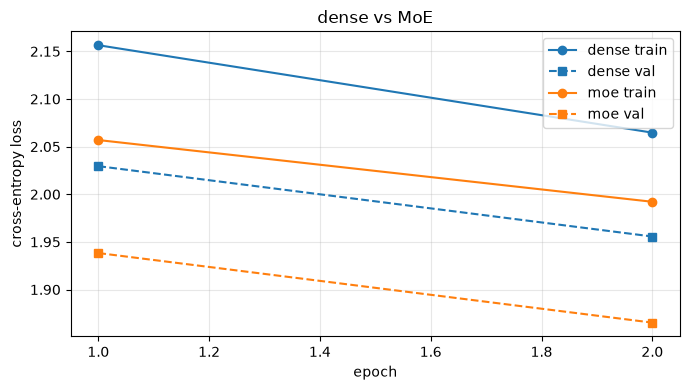

In [28]:
history_moe = run_training(build_trainer(moe_model, "./checkpoints/tp1_moe"), epochs=EPOCHS)
plot_losses({"dense": history, "moe": history_moe}, title="dense vs MoE")
free()

# Task VII — expert utilization

A MoE that routes 90% of its tokens to one expert is a dense model that wastes
memory. Measure whether yours actually spreads the load.

Using `last_indices` (stored by your `MoELayer.forward`), run a few validation
batches and, per layer, count how many tokens went to each expert. Plot it as a
bar chart, one group per layer, and print the fraction of tokens each expert saw.

A perfectly balanced layer sends `k / E` of the tokens to each expert.

layer 1: E0=0.378  E1=0.642  E2=0.629  E3=0.351
layer 2: E0=0.001  E1=0.003  E2=0.999  E3=0.997
balanced would be k/E = 0.500 per expert


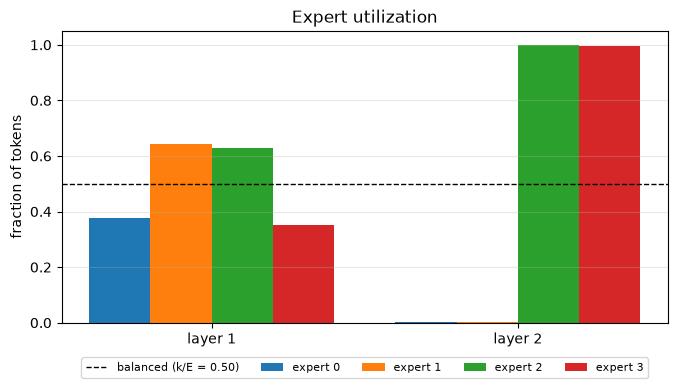


same architecture, untrained:
layer 1: E0=0.494  E1=0.400  E2=0.518  E3=0.587
layer 2: E0=0.657  E1=0.477  E2=0.382  E3=0.483
balanced would be k/E = 0.500 per expert


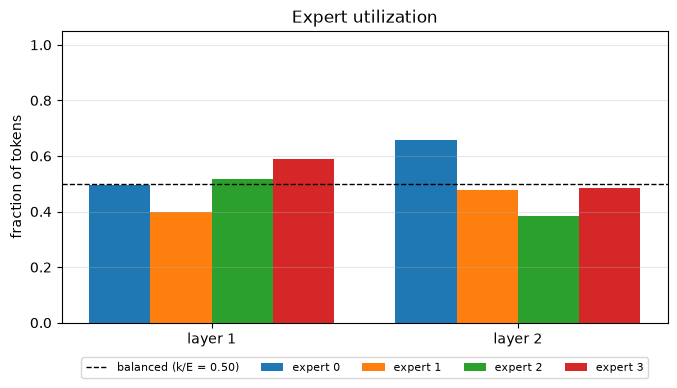

In [29]:
def _report_utilization(utilization, k):
    n_layer, E = utilization.shape
    for layer, row in enumerate(utilization):
        print(f"layer {layer + 1}: " + "  ".join(f"E{e}={f:.3f}" for e, f in enumerate(row.tolist())))
    print(f"balanced would be k/E = {k / E:.3f} per expert")

    width = 0.8 / E
    plt.figure(figsize=(7, 4))
    for e in range(E):
        xs = [layer + (e - (E - 1) / 2) * width for layer in range(n_layer)]
        plt.bar(xs, utilization[:, e].tolist(), width=width, label=f"expert {e}")
    plt.axhline(k / E, color="black", linestyle="--", linewidth=1, label=f"balanced (k/E = {k / E:.2f})")
    plt.xticks(range(n_layer), [f"layer {i + 1}" for i in range(n_layer)])
    plt.ylabel("fraction of tokens")
    plt.ylim(0, 1.05)
    plt.title("Expert utilization")
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=8)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def expert_utilization(model, loader, n_batches: int = 20, show: bool = True):
    """
    Returns a tensor of shape (n_layer, num_experts) with the fraction of tokens
    routed to each expert, and prints and plots it unless `show=False`.

    Hint: for each block, model.blocks[i].ff.moe.last_indices holds the (N, k)
    selection from the most recent forward pass. Use torch.bincount.
    """
    was_training = model.training
    model.eval()
    dev = next(model.parameters()).device

    moes = [block.ff.moe for block in model.blocks]
    E = model.config.moe_args.num_experts
    k = model.config.moe_args.num_experts_per_token

    tokens_per_expert = torch.zeros(len(moes), E)
    n_tokens = 0
    for i, (x, _) in enumerate(loader):
        if i >= n_batches:
            break
        model(x.to(dev))
        # last_indices only holds the most recent forward pass, so read it every batch.
        for layer, moe in enumerate(moes):
            tokens_per_expert[layer] += torch.bincount(moe.last_indices.flatten(), minlength=E).cpu()
        n_tokens += moes[0].last_indices.shape[0]

    # Divide by tokens, not by selections: a balanced layer gives k/E to every expert,
    # and each row sums to k.
    utilization = tokens_per_expert / n_tokens

    model.train(was_training)
    if show:
        _report_utilization(utilization, k)
    return utilization


utilization = expert_utilization(moe_model, val_loader)

print("\nsame architecture, untrained:")
torch.manual_seed(0)
_ = expert_utilization(TinyGPT(moe_config).to(device), val_loader)

## Questions

1. If one expert is starved, explain the feedback loop that got you there. Why is it
   self-reinforcing?
2. Routing is a `topk`, which has no useful gradient. So how does the gate learn
   anything at all? Trace the path from the loss back to `gate.proj.weight`.

---

1. In our run layer 2 collapsed completely. Experts 2 and 3 get 99.9% and 99.7% of the tokens, and experts 0 and 1 get 0.1% and 0.3%. Since each token picks 2 experts, practically every token picks the same pair, so layer 2 ended up working like a dense FFN made of two experts, with the other two as dead weight. Layer 1 is uneven (0.35 to 0.64) but all four experts are in use. The same architecture with random weights splits the tokens roughly evenly (0.38 to 0.66, balanced is 0.50), so the collapse happens during training.

    The loop goes like this. An expert only learns from the tokens it receives. At the start some experts get a few more tokens just by chance, they get more updates and improve, so the gate, which is trying to lower the loss, sends them even more. The starved one gets almost no updates, stays bad, and the gate has even less reason to pick it, and nothing in the loss pushes the other way because there's no load-balancing term.

2. Through the weights, not through the choice. The path from the loss to `gate.proj.weight` is:

    loss → layer output (`sum_e w_e · expert_e(x)`) → `weights = softmax(top_vals)` → `top_vals` → `logits = gate.proj(x)` → `gate.proj.weight`

    `torch.topk` returns indices and values. The indices are discrete and carry no gradient, but the values are differentiable, so the gradient flows through them. The backward of `topk` only writes gradient into the positions it selected, so the logits of the unselected experts get exactly zero, and since the softmax is only over the `k` selected values, the gradients on the selected logits of each token sum to zero.

    So the gate never gets a signal like "expert 3 would have been better here", it can only move weight between the experts it already picked, up for the one that helps and down for the one that doesn't. The choice can still change over time. If it keeps pushing a selected expert down, its logit can drop below an unselected one and they swap places in the top-k. But an expert that isn't selected can't do anything to get selected, and that's why the loop from question 1 is so hard to break.

# Task VIII — DeepSeekMoE

Your current MoE is a legacy design: `E` equal experts, pick the top `k`. Read
[DeepSeekMoE (Dai et al., 2024)](https://arxiv.org/abs/2401.06066) and implement its two
changes. They are what makes DeepSeek-V2 and V3 and modern verisons use, and both are small deltas on the
layer you already wrote.

**Fine-grained expert segmentation.** Split each expert into `m` smaller ones: multiply
`num_experts` and `num_experts_per_token` by `m`, and divide each expert's hidden width by
`m`. Total parameters and per-token compute are unchanged. What grows is the number of
routing *combinations* — from "choose 2 of 4" to "choose 4 of 8" — so a token can express
a more specific mixture.

**Shared expert isolation.** Reserve `num_shared_experts` experts that every token passes
through, always, outside the top-k. The argument: knowledge common to all tokens
(punctuation, spacing, basic English) otherwise has to be duplicated inside every routed
expert. Hand it to a shared expert and the routed ones are free to specialise.

Implement `DeepSeekMoELayer`. Both settings live in `MoEArgs` already
(`num_shared_experts`, `expert_hidden_mult`); `Expert` reads the width from config, so you
should not need to touch it.

Then train it against your Task VI MoE at **matched active parameters** and report loss,
expert utilization, and per-step time.

### Set your expectations first

Write down what you predict, then measure. This model is 2 layers at `n_embd=64` trained
on 100k characters. Segmenting 4 experts into 8 leaves each with a hidden width of 128.
The paper's results are at 2B–145B parameters on hundreds of billions of tokens.

**A null result here is the correct result, and explaining it is the task.** Reproducing a
2024 architecture and then honestly reporting that its benefit does not appear at your
scale is worth more than a number that went the right way by luck.

### What I expected before training it

- Loss: about the same as the Task VI MoE, maybe a little better. The paper's gains come from experts specializing in different things, and with 2 layers, `n_embd=64` and 100k characters I don't think there's much to specialize on.
- Expert utilization: more balanced than the MoE. The shared expert can take the "generalist" role that one routed expert ended up taking in Task VII, so the routed ones should have less reason to collapse, and with 8 smaller experts there are more combinations to choose from.
- Time per step: slower. Each layer now runs 9 experts (8 routed + 1 shared) instead of 4, and the MoE was already much slower per step than the dense model.


In [30]:
class DeepSeekMoELayer(nn.Module):
    """
    MoE with fine-grained expert segmentation and shared experts (arXiv:2401.06066).

    Shared experts run for every token, outside the top-k. Routed experts are selected as
    before. Store last_indices / last_gate_probs for the routed experts only, so Task VII's
    utilization plot still works.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        args = config.moe_args
        self.args = args

        self.shared = nn.ModuleList([Expert(config) for _ in range(args.num_shared_experts)])

        # Expert reads its hidden width from moe_args.expert_hidden_mult, so fine-grained
        # segmentation needs no change to it.
        self.routed = MoELayer(
            experts=[Expert(config) for _ in range(args.num_experts)],
            gate=Gate(config),
            moe_args=args,
        )

        # Task VII reads the routing from block.ff.moe, which is this module.
        self.last_indices = None
        self.last_gate_probs = None
        self.last_gate_probs_grad = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.routed(x)
        for expert in self.shared:
            out = out + expert(x)

        self.last_indices = self.routed.last_indices
        self.last_gate_probs = self.routed.last_gate_probs
        self.last_gate_probs_grad = self.routed.last_gate_probs_grad
        return out


class DeepSeekMoEFFN(nn.Module):
    """Drop-in for config.ff_class, like MoEFFN."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = DeepSeekMoELayer(config)

    def forward(self, x):
        return self.moe(x)


In [31]:
# Fine-grained segmentation is compute-neutral: 4 experts x top-2 at 4.0x hidden becomes
# 8 x top-4 at 2.0x, and the active FFN parameters per token are identical either way.
# What changes is the number of routing combinations, from C(4,2)=6 to C(8,4)=70.
#
# The shared expert is NOT free -- it runs for every token, adding one expert's worth on
# top. Question 1 asks you to work out exactly how much, and whether that undermines the
# comparison.
#
# SEGMENTS=2 keeps this affordable: 8 routed experts + 1 shared is 9 sequential expert
# calls per layer, against 17 at SEGMENTS=4. The paper segments far more aggressively --
# set this to 4 if you have the compute and want to see whether it changes anything.
SEGMENTS = 2

ds_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=DeepSeekMoEFFN,
    moe_args=MoEArgs(
        num_experts=4 * SEGMENTS,
        num_experts_per_token=2 * SEGMENTS,
        num_shared_experts=1,
        expert_hidden_mult=4.0 / SEGMENTS,
    ),
)

ds_model = TinyGPT(ds_config).to(device)
if device == "cuda":
    ds_model = torch.compile(ds_model)

describe(moe_model, "MoE (Task VI)")
describe(ds_model, "DeepSeekMoE")


MoE (Task VI): 305,088 parameters | 305,088 trainable (100.00%)
DeepSeekMoE: 339,264 parameters | 339,264 trainable (100.00%)


mixed precision: on (bfloat16)


val_loss 1.76706:   1%|▋                                                                                                            | 1/155 [00:00<00:44,  3.43it/s]W1001 19:52:10.549000 128996 torch/_dynamo/convert_frame.py:2008] [5/8] torch._dynamo hit config.recompile_limit (8)
W1001 19:52:10.549000 128996 torch/_dynamo/convert_frame.py:2008] [5/8]    function: 'forward' (/tmp/ipykernel_128996/3327672097.py:19)
W1001 19:52:10.549000 128996 torch/_dynamo/convert_frame.py:2008] [5/8]    last reason: 5/7: 2 <= x.size()[0]  # return F.linear(input, self.weight, self.bias)  # nn/modules/linear.py:134 in forward (user code shown is first use of this value--the guard itself is not due user code but due to 0/1 specialization in the framework; to avoid specialization try torch._dynamo.decorators.mark_unbacked(tensor, dim))
W1001 19:52:10.549000 128996 torch/_dynamo/convert_frame.py:2008] [5/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1001 19:52:10.549000 128996 torch/_d

epoch 1/2 | train 2.0290 | val 1.9145


val_loss 2.09565: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 167.64it/s]


epoch 2/2 | train 1.9494 | val 1.8474


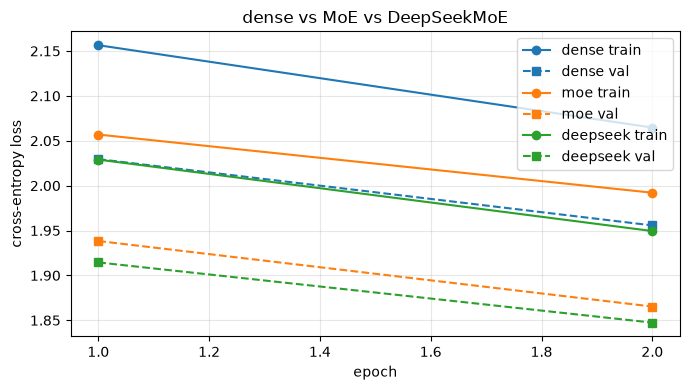

In [32]:
history_ds = run_training(build_trainer(ds_model, "./checkpoints/tp1_deepseek"), epochs=EPOCHS)
plot_losses({"dense": history, "moe": history_moe, "deepseek": history_ds},
            title="dense vs MoE vs DeepSeekMoE")
free()


### Measuring DeepSeekMoE

Question 1 asks for the Task VII utilization plot again, now on DeepSeekMoE. It only counts
the routed experts, since the shared expert sees every token by design.

layer 1: E0=0.353  E1=0.519  E2=0.461  E3=0.608  E4=0.582  E5=0.604  E6=0.377  E7=0.496
layer 2: E0=0.931  E1=0.977  E2=0.773  E3=0.050  E4=0.029  E5=0.142  E6=0.124  E7=0.974
balanced would be k/E = 0.500 per expert


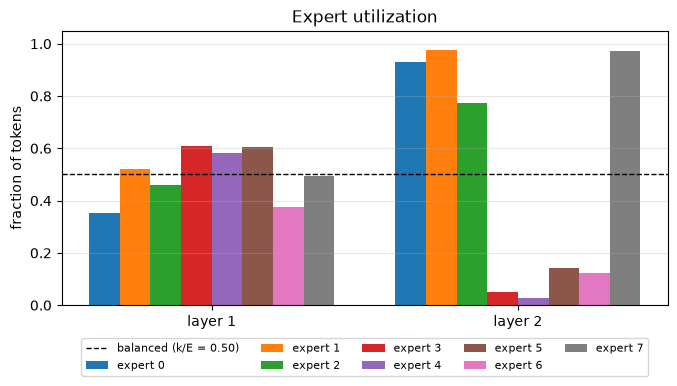

In [33]:
ds_utilization = expert_utilization(ds_model, val_loader)

Question 2 asks whether the shared expert does real work. `shared_expert_norms` compares, per
layer, the average size (norm) of its output with the output of the routed mixture and of each
routed expert, on one validation batch. A hook captures the input of each MoE layer, so all
the experts can be evaluated on the same tokens.

In [34]:
@torch.no_grad()
def shared_expert_norms(model, x):
    model = getattr(model, "_orig_mod", model).eval()
    print("average output norm per token:")
    for layer, moe in enumerate((block.ff.moe for block in model.blocks), start=1):
        ffn_input = []
        hook = moe.register_forward_pre_hook(lambda module, args: ffn_input.append(args[0]))
        model(x)
        hook.remove()

        routed = moe.routed(ffn_input[0]).norm(dim=-1).mean()
        tokens = ffn_input[0].reshape(-1, ffn_input[0].shape[-1])
        shared = sum(expert(tokens) for expert in moe.shared).norm(dim=-1).mean()
        chosen = moe.routed.last_indices
        single = [expert(tokens[(chosen == e).any(dim=-1)]).norm(dim=-1).mean()
                  for e, expert in enumerate(moe.routed.experts) if (chosen == e).any()]
        print(f"  layer {layer}: shared {shared:.1f} | routed mixture {routed:.1f} "
              f"(shared is {100 * shared / routed:.0f}% of it) | "
              f"one routed expert {min(single):.1f} to {max(single):.1f}")


shared_expert_norms(ds_model, next(iter(val_loader))[0].to(device))

average output norm per token:
  layer 1: shared 7.4 | routed mixture 19.4 (shared is 38% of it) | one routed expert 18.8 to 22.6
  layer 2: shared 2.4 | routed mixture 6.4 (shared is 39% of it) | one routed expert 4.8 to 13.9


The norm alone doesn't say whether the shared expert matters. `loss_increase_when_switched_off` replaces the output of some experts with zeros and measures how much the validation loss goes up, for the shared expert of each layer, for both shared experts together, and for the routed expert whose removal hurts the most in each layer.

In [35]:
@torch.no_grad()
def loss_increase_when_switched_off(model, loader):
    model = getattr(model, "_orig_mod", model).eval()
    batches = [(x.to(device), y.to(device)) for x, y in loader]
    moes = [block.ff.moe for block in model.blocks]

    def val_loss():
        losses = [F.cross_entropy(model(x).flatten(0, 1), y.flatten()).item() for x, y in batches]
        return sum(losses) / len(losses)

    def increase(switched_off):
        hooks = [m.register_forward_hook(lambda module, args, out: torch.zeros_like(out))
                 for m in switched_off]
        loss = val_loss()
        for hook in hooks:
            hook.remove()
        return loss - baseline

    baseline = val_loss()
    print(f"validation loss {baseline:.3f}; increase when switched off:")
    for layer, moe in enumerate(moes, start=1):
        print(f"  shared expert, layer {layer}: +{increase(moe.shared):.3f}")
    print(f"  shared experts, both layers: +{increase([e for moe in moes for e in moe.shared]):.3f}")
    for layer, moe in enumerate(moes, start=1):
        worst = max(increase([expert]) for expert in moe.routed.experts)
        print(f"  one routed expert, layer {layer} (worst case): +{worst:.3f}")


loss_increase_when_switched_off(ds_model, val_loader)

validation loss 1.847; increase when switched off:
  shared expert, layer 1: +0.134
  shared expert, layer 2: +0.083
  shared experts, both layers: +0.351
  one routed expert, layer 1 (worst case): +0.136
  one routed expert, layer 2 (worst case): +0.031


### At matched active parameters

The comparison above is not at matched active parameters, because the shared expert adds one expert's
worth of parameters to every token. With `num_experts_per_token=3` instead of 4, DeepSeekMoE
uses 3 routed experts plus the shared one, almost exactly the active FFN parameters of the
Task VI MoE. The cell below checks that, and then trains both models with 3 seeds, because one
run cannot tell a small difference apart from noise. These runs use the eager model, without
`torch.compile`, and their checkpoints go to `./checkpoints/seeds/`.

In [36]:
from dataclasses import replace

SEEDS = (0, 1, 2)
ds_matched_config = replace(ds_config, moe_args=replace(ds_config.moe_args, num_experts_per_token=3))


def active_ffn_params(config) -> int:
    """FFN parameters one token uses in one layer: its routed experts plus the shared ones."""
    args = config.moe_args
    per_expert, _ = count_parameters(Expert(config))
    return (args.num_experts_per_token + args.num_shared_experts) * per_expert


def train_with_seed(config, seed: int, save_dir: str, make_trainer=build_trainer):
    """Trains a fresh model from a fixed seed; returns its final validation loss and expert utilization."""
    torch.manual_seed(seed)
    net = TinyGPT(config).to(device)
    history = run_training(make_trainer(net, save_dir), epochs=EPOCHS)
    utilization = expert_utilization(net, val_loader, show=False)
    del net
    free()
    return history["val"][-1], utilization


for name, cfg in (("MoE (Task VI)", moe_config), ("DeepSeekMoE, k=4", ds_config),
                  ("DeepSeekMoE, k=3", ds_matched_config)):
    print(f"{name:17s} active FFN parameters per token and layer: {active_ffn_params(cfg):,}")

seed_runs = {"MoE": [], "DeepSeekMoE k=3": []}
for seed in SEEDS:
    seed_runs["MoE"].append(train_with_seed(moe_config, seed, f"./checkpoints/seeds/moe_{seed}"))
    seed_runs["DeepSeekMoE k=3"].append(
        train_with_seed(ds_matched_config, seed, f"./checkpoints/seeds/deepseek_k3_{seed}"))

MoE (Task VI)     active FFN parameters per token and layer: 66,176
DeepSeekMoE, k=4  active FFN parameters per token and layer: 82,880
DeepSeekMoE, k=3  active FFN parameters per token and layer: 66,304
mixed precision: on (bfloat16)


val_loss 2.20493: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 315.41it/s]


epoch 1/2 | train 2.0252 | val 1.9379


val_loss 2.16847: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 321.42it/s]


epoch 2/2 | train 1.9670 | val 1.8733
mixed precision: on (bfloat16)


...

epoch 2/2 | train 1.9629 | val 1.8532
mixed precision: on (bfloat16)


val_loss 2.19242: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 200.48it/s]


epoch 1/2 | train 1.9853 | val 1.8854


val_loss 2.09665: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 201.14it/s]


epoch 2/2 | train 1.8860 | val 1.8211


Final validation loss of every run, and per layer the share of tokens of the least and the most
used expert. A balanced layer gives every expert `k/E`, which is 0.50 for the MoE and 0.375 for
DeepSeekMoE with k=3.

In [37]:
def summarize_losses(runs: dict):
    print(f"{'validation loss':<22}" + "".join(f"{'seed ' + str(s):>9}" for s in SEEDS) + f"{'mean':>9}{'std':>8}")
    for name, results in runs.items():
        losses = torch.tensor([loss for loss, _ in results])
        print(f"{name:<22}" + "".join(f"{loss:>9.3f}" for loss in losses.tolist())
              + f"{losses.mean():>9.3f}{losses.std():>8.3f}")


def summarize_routing(runs: dict):
    for name, results in runs.items():
        for seed, (_, utilization) in zip(SEEDS, results):
            layers = "   ".join(f"layer {i + 1}: {row.min():.2f} to {row.max():.2f}"
                                for i, row in enumerate(utilization))
            print(f"{name:<22} seed {seed}   {layers}")


summarize_losses(seed_runs)
print()
summarize_routing(seed_runs)

validation loss          seed 0   seed 1   seed 2     mean     std
MoE                       1.873    1.865    1.853    1.864   0.010
DeepSeekMoE k=3           1.838    1.854    1.821    1.838   0.017

MoE                    seed 0   layer 1: 0.41 to 0.57   layer 2: 0.00 to 1.00
MoE                    seed 1   layer 1: 0.31 to 0.64   layer 2: 0.00 to 0.99
MoE                    seed 2   layer 1: 0.42 to 0.56   layer 2: 0.00 to 1.00
DeepSeekMoE k=3        seed 0   layer 1: 0.12 to 0.54   layer 2: 0.00 to 1.00
DeepSeekMoE k=3        seed 1   layer 1: 0.22 to 0.59   layer 2: 0.00 to 0.97
DeepSeekMoE k=3        seed 2   layer 1: 0.17 to 0.64   layer 2: 0.01 to 0.98


## Questions

1. Re-run the Task VII utilization plot on the DeepSeekMoE model. With 8 routed experts
   instead of 4, is the load more or less balanced, and why would you expect that
   *before* looking?
2. The shared expert receives every token. Inspect its output magnitude against a routed
   expert's. Is it doing what the paper claims — absorbing common structure — or has it
   just become a second dense FFN?
3. The paper reports clear gains; you probably did not reproduce them. Give the most
   likely reason, and describe the smallest experiment that would test whether scale is
   the explanation.

---

1. Before looking I expected it to be more balanced. In a plain MoE one expert can become a "generalist" that helps every token and the gate keeps feeding it. Here the shared expert can take that role, so the routed ones have less reason to collapse. And with 8 smaller experts there are more combinations, so tokens don't all need the same few experts.

    It was only half right. Layer 1 is more balanced, all eight experts get between 0.35 and 0.61 of the tokens, on average 0.08 away from 0.50, against 0.14 for the MoE. Layer 2 collapsed again, four experts get 0.77 to 0.98 of the tokens and the other four 0.14 or less (expert 4 only 0.03), so with k=4 most tokens end up with mostly the same four. It's the same shape as in the MoE, where layer 2 sent almost everything to 2 of its 4 experts, half of the experts doing all the work. The shared expert didn't stop the starvation loop from Task VII.

2. Its output is smaller than the routed experts' but not insignificant. On a validation batch the average norm is 7.4 in layer 1 and 2.4 in layer 2, about 38% of the routed mixture in both layers (19.4 and 6.4), while a single routed expert gives 18.8 to 22.6 in layer 1 and 4.8 to 13.9 in layer 2. So it doesn't dominate the sum.

    The norm alone doesn't say much, so I switched it off and measured the validation loss:

    | Switched off | Loss increase |
    |---|---|
    | Shared expert, layer 1 | +0.134 |
    | Shared expert, layer 2 | +0.083 |
    | Shared experts, both layers | +0.351 |
    | One routed expert, layer 1 (worst case) | +0.136 |
    | One routed expert, layer 2 (worst case) | +0.031 |

    It depends on the layer. In layer 2, removing the shared expert hurts almost 3 times more than removing any routed expert (+0.083 vs +0.031), which goes with the paper's idea of an expert that holds what every token needs. In layer 1 it hurts about as much as the most important routed expert (+0.134 vs +0.136), so there it looks like just one more expert. Removing both costs +0.351, more than the two separately (+0.217), which makes sense since layer 2 also gets a worse input when layer 1 loses its shared expert.

    From this I can't really tell if it absorbs common structure or if it's just a second small dense FFN. It sees every token, so in practice it is a dense FFN running next to the routed ones, and I didn't look at what it learned. Also, a routed expert only sees part of the tokens, so the comparison isn't exactly like for like.

3. We do see a gain, but a small one, nothing like the paper's. I think the main reason is scale. The model has 2 layers, 64 dimensions, a vocabulary of 61 characters and 100k characters of text, for 2 epochs. The paper's gains come from experts specializing in different knowledge, and here there isn't much to specialize on. The routing isn't healthy either, in layer 2 half of the experts are almost unused, so most of the extra combinations from splitting the experts never get used.

    My first DeepSeekMoE run (k=4) got 1.847 against 1.865 for the MoE, but that wasn't a fair comparison, the shared expert adds 25% more active FFN parameters per token (82,880 vs 66,176). With k=3 the active parameters match (66,304 vs 66,176), so I trained both models with 3 seeds. DeepSeekMoE k=3 was lower in all three seeds, 1.838 ± 0.017 against 1.864 ± 0.010, a gap of 0.026 on average. With only 3 seeds that isn't conclusive (a t-test gives p ≈ 0.1), so I'd call it at most a hint of a small gain, pretty close to the null result the task expected. It also costs time. A training step took about 15.5 ms against 9.8 ms for the MoE, since each layer runs 9 expert calls instead of 4 (see Task IX).

    To check whether scale is the explanation I'd repeat exactly this comparison (k=3, 3 seeds) at a bigger size, for example `n_embd=256`, with everything else fixed. If the gap grows with the size and stays above the seed spread, that would explain why the paper sees clear gains and we only see a small one.

# Task IX — make it fast

Open-ended. There is no reference solution and no checker.

You measured it in Task VI: the MoE trains at roughly **30x the per-step cost** of the
dense model, for *less* arithmetic. Task VIII made it worse — 16 experts instead of 4 means
16 sequential expert calls per layer.

**Make it faster. Report what you tried, what worked, what did not, and why.**

Rules: the output must stay numerically equivalent to your Task V implementation (write a
test that proves it), and the model must still train. Beyond that, anything goes.

Some directions, not a checklist — you are not required to use any of them:

- Time the *second* epoch, never the first: lazy kernel compilation makes epoch 1 about
  2.4x slower and will flatter or ruin any change you make.
- Where does the time actually go? Profile before optimising. `torch.profiler`, or time the
  pieces by hand. The answer is not where most people guess.
- `torch.where` returns a variable-length tensor, so it forces a GPU→CPU synchronisation.
  You call it once per expert per layer.
- Sorting tokens by expert once turns a scatter into contiguous slices.
- Padding each expert to a fixed capacity makes the shapes static, which is what lets you
  batch experts into one `torch.bmm`. What does capacity padding cost you in correctness?
- Small matmuls leave the GPU idle. How few kernel launches could this take?

**Deliverable:** your fastest correct implementation, the equivalence test, a before/after
measurement on the same hardware, and a short write-up of the reasoning — including the
things you tried that made it slower. Those are often the most informative part.


### The three variants

I kept the three versions I tried so they can be compared. All of them keep Task V's parameters and `state_dict` and store the same `last_indices` and `last_gate_probs`, so `use_fast_moe` can swap them into a model even after training. They route exactly like Task V (gate, top-k, softmax over the k selected experts) and only change how the experts are run, so `RoutedMoE` has the routing part and each variant only implements `run_experts`.

In [38]:
import copy
import statistics
from functools import partial


class RoutedMoE(MoELayer):
    """Task V's routing, split into steps that the variants below reuse."""

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.reshape(-1, C)
        logits, indices, weights = self.route(x_flat)
        out = self.run_experts(x_flat, indices, weights)
        self.remember_routing(logits, indices)
        return out.view(B, T, C)

    def route(self, x_flat):
        logits = self.gate(x_flat)
        top_vals, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        return logits, indices, F.softmax(top_vals, dim=-1)

    def run_experts(self, x_flat, indices, weights):
        raise NotImplementedError

    def remember_routing(self, logits, indices):
        self.last_indices = indices.detach()
        probs = F.softmax(logits, dim=-1)
        self.last_gate_probs = probs.detach()
        self.last_gate_probs_grad = probs

    @staticmethod
    def combine(sorted_outputs, order, weights, k):
        """Weight outputs sorted by expert, put them back in (token, slot) order, and sum the k slots."""
        weighted = sorted_outputs * weights.reshape(-1).index_select(0, order).unsqueeze(-1)
        inverse = torch.empty_like(order)                       # inverse permutation of `order`
        inverse[order] = torch.arange(order.numel(), device=order.device)
        return weighted.index_select(0, inverse).view(-1, k, weighted.shape[-1]).sum(dim=1)


def use_fast_moe(model, cls):
    """
    Swap every MoELayer of `model` for `cls`, including the routed part of DeepSeekMoE.
    Changing `__class__` is safe because the variants add no parameters or buffers, only methods.
    """
    for module in model.modules():
        if type(module) is MoELayer:
            module.__class__ = cls
    return model

**`FastMoELayer`** keeps Task V's loop over the experts and removes small costs. It uses one 1-D
`nonzero` per expert instead of a 2-D `where`, `F.linear` and an in-place ReLU instead of
calling the expert's `nn.Sequential`, and an in-place `index_add_` instead of a new `(N, C)`
tensor per expert. It visits the experts in the same order and does the same arithmetic.

In [39]:
class FastMoELayer(RoutedMoE):
    def run_experts(self, x_flat, indices, weights):
        k = indices.shape[1]
        flat_experts = indices.reshape(-1)
        flat_weights = weights.reshape(-1)
        out = torch.zeros_like(x_flat)
        for e, expert in enumerate(self.experts):
            slots = torch.nonzero(flat_experts == e).squeeze(1)
            if slots.numel() == 0:
                continue
            tokens = slots // k                                       # slot i belongs to token i // k
            first, second, dropout = expert.net[0], expert.net[2], expert.net[3]
            hidden = F.relu_(F.linear(x_flat.index_select(0, tokens), first.weight, first.bias))
            y = dropout(F.linear(hidden, second.weight, second.bias))
            out.index_add_(0, tokens, (y * flat_weights.index_select(0, slots).unsqueeze(-1)).to(out.dtype))
        return out

**`SortMoELayer`** sorts the (token, slot) pairs by expert once. Each expert then reads a
contiguous slice, and one `argsort` plus one `bincount` replace the `E` calls to `where`.

In [40]:
class SortMoELayer(RoutedMoE):
    def run_experts(self, x_flat, indices, weights):
        k = indices.shape[1]
        flat_experts = indices.reshape(-1)
        order = torch.argsort(flat_experts)
        x_sorted = x_flat.index_select(0, order // k)             # slot i belongs to token i // k
        counts = torch.bincount(flat_experts, minlength=len(self.experts)).tolist()
        outputs, start = [], 0
        for expert, n in zip(self.experts, counts):
            if n:
                outputs.append(expert(x_sorted[start:start + n]))
                start += n
        return self.combine(torch.cat(outputs), order, weights, k).to(x_flat.dtype)

**`CapacityMoELayer`** gives every expert the same number of rows, the load of the busiest
expert, filling the gaps with zeros. With equal shapes, all the experts run at once in two
batched matmuls (`baddbmm`) instead of one pair of small matmuls per expert. No token is
dropped, so the result stays equal to Task V's, the price is the padding.

In [41]:
class CapacityMoELayer(RoutedMoE):
    def run_experts(self, x_flat, indices, weights):
        N, k = indices.shape
        E = len(self.experts)
        flat_experts = indices.reshape(-1)
        order = torch.argsort(flat_experts)
        experts_sorted = flat_experts.index_select(0, order)
        counts = torch.bincount(flat_experts, minlength=E)
        capacity = int(counts.max())
        # position of each sorted slot inside its expert's block of rows
        first_row_of_expert = counts.cumsum(0) - counts
        row_in_expert = torch.arange(N * k, device=x_flat.device) - first_row_of_expert.index_select(0, experts_sorted)

        padded = x_flat.new_zeros(E, capacity, x_flat.shape[-1])
        padded[experts_sorted, row_in_expert] = x_flat.index_select(0, order // k)

        W1, b1, W2, b2 = self.stacked_weights()
        out = torch.baddbmm(b2, torch.relu(torch.baddbmm(b1, padded, W1)), W2)
        dropout = self.experts[0].net[3]
        return self.combine(dropout(out[experts_sorted, row_in_expert]), order, weights, k).to(x_flat.dtype)

    def stacked_weights(self):
        first = [expert.net[0] for expert in self.experts]
        second = [expert.net[2] for expert in self.experts]
        return (torch.stack([layer.weight for layer in first]).transpose(1, 2),
                torch.stack([layer.bias for layer in first]).unsqueeze(1),
                torch.stack([layer.weight for layer in second]).transpose(1, 2),
                torch.stack([layer.bias for layer in second]).unsqueeze(1))

### Proving they are still correct

`check_fast_moe` builds Task V's `MoELayer` and a variant with the same weights and compares
them in eval mode, checking the output, the gradient of the input, the gradient of every parameter and
the stored routing. It runs several `(E, k)` settings, each one with balanced routing and with
collapsed routing, where some experts receive no tokens at all.

In [42]:
def _relative_error(a, b):
    return ((a - b).abs().max() / b.abs().max().clamp_min(1e-12)).item()


def check_fast_moe(cls, tol=1e-5):
    for E, k, mult in [(4, 2, 4.0), (8, 4, 2.0), (4, 1, 4.0), (4, 4, 4.0)]:
        for routing in ("balanced", "collapsed"):
            cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                            moe_args=MoEArgs(num_experts=E, num_experts_per_token=k, expert_hidden_mult=mult))
            torch.manual_seed(0)
            ref = MoELayer([Expert(cfg) for _ in range(E)], Gate(cfg), cfg.moe_args).eval()
            x = torch.randn(3, 20, 32)
            if routing == "collapsed" and k < E:
                with torch.no_grad():                    # every token prefers the first half of the experts
                    ref.gate.proj.weight[: E // 2] = 0.5
                    ref.gate.proj.weight[E // 2:] = -0.5
                x = x + 2.0
            new = use_fast_moe(copy.deepcopy(ref), cls)

            xa, xb = x.clone().requires_grad_(True), x.clone().requires_grad_(True)
            ya, yb = ref(xa), new(xb)
            (ya ** 2).sum().backward()
            (yb ** 2).sum().backward()

            tag = f"E={E} k={k} {routing}"
            assert _relative_error(yb, ya) < tol, f"{tag}: output differs ({_relative_error(yb, ya):.1e})"
            assert _relative_error(xb.grad, xa.grad) < tol, f"{tag}: input gradient differs"
            for (n, pa), pb in zip(ref.named_parameters(), new.parameters()):
                if pa.grad is None or pa.grad.abs().max() == 0:       # an expert that received no tokens
                    assert pb.grad is None or pb.grad.abs().max() == 0, f"{tag}: {n} should get no gradient"
                else:
                    assert _relative_error(pb.grad, pa.grad) < tol, f"{tag}: gradient of {n} differs"
            assert torch.equal(ref.last_indices, new.last_indices), f"{tag}: last_indices differ"
            assert torch.allclose(ref.last_gate_probs, new.last_gate_probs, atol=1e-6), f"{tag}: last_gate_probs differ"
    print(f"{cls.__name__}: equivalent to Task V's MoELayer (output, input grad, parameter grads, routing)")


for cls in (FastMoELayer, SortMoELayer, CapacityMoELayer):
    check_fast_moe(cls)

FastMoELayer: equivalent to Task V's MoELayer (output, input grad, parameter grads, routing)
SortMoELayer: equivalent to Task V's MoELayer (output, input grad, parameter grads, routing)
CapacityMoELayer: equivalent to Task V's MoELayer (output, input grad, parameter grads, routing)


The variant must also still train. `check_fast_moe_trains` trains a model with Task V's layer
and one with the variant for 40 steps, with the same seed and the same batches, and compares
the two loss curves. With dropout, the curves only match exactly if the variant draws the
dropout masks in the same order as Task V.

In [43]:
def check_fast_moe_trains(cls, steps: int = 40):
    it = iter(train_loader)
    batches = [next(it) for _ in range(steps)]
    curves = []
    for layer_cls in (MoELayer, cls):
        torch.manual_seed(0)
        m = use_fast_moe(TinyGPT(GPTConfig(vocab_size=tokenizer.vocab_size, ff_class=MoEFFN,
                                           moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))),
                         layer_cls)
        opt = AdamW(m.parameters(), lr=1e-3)
        m.train()
        losses = []
        for xb, yb in batches:
            out = m(xb)
            loss = F.cross_entropy(out.reshape(-1, out.size(-1)), yb.reshape(-1))
            loss.backward()
            opt.step()
            opt.zero_grad(set_to_none=True)
            losses.append(loss.item())
        curves.append(losses)
    gap = max(abs(a - b) for a, b in zip(*curves))
    print(f"loss step 1 -> {steps}: Task V {curves[0][0]:.3f} -> {curves[0][-1]:.3f} | "
          f"{cls.__name__} {curves[1][0]:.3f} -> {curves[1][-1]:.3f}"
          f" | largest gap between the two curves {gap:.1e}")
    assert curves[1][-1] < curves[1][0], f"{cls.__name__} does not train"


check_fast_moe_trains(CapacityMoELayer)

loss step 1 -> 40: Task V 41.898 -> 5.110 | CapacityMoELayer 41.880 -> 5.106 | largest gap between the two curves 1.0e-01


### Measuring

CUDA kernels run asynchronously, so every timing waits for the GPU (`_sync`) before reading
the clock. The variants run interleaved, round by round, so noise on the machine hits all of
them the same, and the median of the rounds is reported.

`benchmark_training_step` times whole training steps (forward, backward and AdamW) of the
Task VI MoE and of DeepSeekMoE with each variant. On a GPU it also counts the kernels
launched per step and the time the GPU is actually busy.

In [44]:
VARIANTS = {"Task V": MoELayer, "fast": FastMoELayer, "sort": SortMoELayer,
            "capacity + bmm": CapacityMoELayer}


def _sync():
    if device == "cuda":
        torch.cuda.synchronize()


def _median_of_interleaved_rounds(timers: dict, rounds: int) -> dict:
    times = {label: [] for label in timers}
    for _ in range(rounds):
        for label, timer in timers.items():
            times[label].append(timer())
    return {label: statistics.median(t) for label, t in times.items()}


def benchmark_training_step(rounds: int = 9, steps: int = 10):
    torch.manual_seed(0)
    batches = [(torch.randint(0, tokenizer.vocab_size, (64, 32), device=device),
             torch.randint(0, tokenizer.vocab_size, (64, 32), device=device))
            for _ in range(steps)]

    def ms_per_step(net, opt):
        _sync()
        start = time.perf_counter()
        for xb, yb in batches:
            out = net(xb)
            F.cross_entropy(out.reshape(-1, out.size(-1)), yb.reshape(-1)).backward()
            opt.step()
            opt.zero_grad(set_to_none=True)
        _sync()
        return (time.perf_counter() - start) / steps * 1000

    def gpu_profile(net, opt):
        with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
            ms_per_step(net, opt)
        gpu_events = [e for e in prof.key_averages() if e.device_type.name == "CUDA"]
        kernels = sum(e.count for e in gpu_events) / steps
        busy_ms = sum(e.self_device_time_total for e in gpu_events) / steps / 1000
        return kernels, busy_ms

    print(f"device: {device}")
    print("whole training step, ms (median of interleaved rounds):")
    for name, cfg in [("MoE (Task VI)", moe_config), ("DeepSeekMoE", ds_config)]:
        models = {}
        for label, cls in VARIANTS.items():
            torch.manual_seed(0)
            net = use_fast_moe(TinyGPT(cfg), cls).to(device).train()
            opt = AdamW(net.parameters(), lr=1e-3)
            ms_per_step(net, opt)                                       # warm-up
            models[label] = (net, opt)
        medians = _median_of_interleaved_rounds(
            {label: partial(ms_per_step, net, opt) for label, (net, opt) in models.items()}, rounds)

        print(f"  {name}")
        for label, (net, opt) in models.items():
            ms = medians[label]
            line = f"    {label:15s} {ms:5.1f} ms ({ms / medians['Task V']:.2f}x)"
            if device == "cuda":
                kernels, busy_ms = gpu_profile(net, opt)
                line += f" | {kernels:5.0f} GPU kernels | GPU busy {busy_ms:4.1f} ms"
            print(line)


benchmark_training_step()

device: cuda
whole training step, ms (median of interleaved rounds):
  MoE (Task VI)


USDT:2026-10-01 19:56:31 128996:128996 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-10-01 19:56:31 128996:128996 SyncActivityProfilerHandler.cpp:46] profiler_stop


    Task V            6.2 ms (1.00x) |   466 GPU kernels | GPU busy  1.9 ms


USDT:2026-10-01 19:56:32 128996:128996 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-10-01 19:56:32 128996:128996 SyncActivityProfilerHandler.cpp:46] profiler_stop


    fast              5.7 ms (0.91x) |   382 GPU kernels | GPU busy  1.7 ms


...

    fast              9.3 ms (0.87x) |   785 GPU kernels | GPU busy  3.0 ms


USDT:2026-10-01 19:56:44 128996:128996 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-10-01 19:56:44 128996:128996 SyncActivityProfilerHandler.cpp:46] profiler_stop


    sort              7.7 ms (0.72x) |   591 GPU kernels | GPU busy  2.8 ms


USDT:2026-10-01 19:56:46 128996:128996 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-10-01 19:56:46 128996:128996 SyncActivityProfilerHandler.cpp:46] profiler_stop


    capacity + bmm    5.9 ms (0.55x) |   418 GPU kernels | GPU busy  3.0 ms


`benchmark_layer` times one MoE layer alone (forward and backward, dropout 0.1), with 4
experts and top-2 as in Task VI, and with 8 experts and top-4 as in DeepSeekMoE.

In [45]:
def benchmark_layer(rounds: int = 9):
    print("single MoE layer, forward + backward, dropout 0.1 (ms, median):")
    for E, k, mult in [(4, 2, 4.0), (8, 4, 2.0)]:
        cfg = GPTConfig(vocab_size=tokenizer.vocab_size, dropout=0.1,
                        moe_args=MoEArgs(num_experts=E, num_experts_per_token=k, expert_hidden_mult=mult))
        torch.manual_seed(0)
        reference = MoELayer([Expert(cfg) for _ in range(E)], Gate(cfg), cfg.moe_args)
        layers = {label: use_fast_moe(copy.deepcopy(reference), cls).to(device).train()
                  for label, cls in VARIANTS.items()}
        x = torch.randn(64, 32, cfg.n_embd, device=device)

        def ms_per_call(layer, n=10):
            _sync()
            start = time.perf_counter()
            for _ in range(n):
                layer(x.clone().requires_grad_(True)).sum().backward()
                layer.zero_grad(set_to_none=True)
            _sync()
            return (time.perf_counter() - start) / n * 1000

        for layer in layers.values():
            ms_per_call(layer, n=3)                                       # warm-up
        medians = _median_of_interleaved_rounds(
            {label: partial(ms_per_call, layer) for label, layer in layers.items()}, rounds)
        print(f"  E={E} k={k}: " + " | ".join(f"{label} {ms:5.1f} ({ms / medians['Task V']:.2f}x)"
                                             for label, ms in medians.items()))


benchmark_layer()

single MoE layer, forward + backward, dropout 0.1 (ms, median):
  E=4 k=2: Task V   2.0 (1.00x) | fast   1.7 (0.85x) | sort   1.4 (0.70x) | capacity + bmm   1.2 (0.61x)
  E=8 k=4: Task V   3.9 (1.00x) | fast   3.3 (0.84x) | sort   2.3 (0.59x) | capacity + bmm   1.6 (0.41x)


## Task IX write-up

I started this on CPU, in an earlier version of the notebook. The timings there were noisy and the variants ended up close to each other, so I don't use them here. The one idea I dropped completely was running every expert on every token and keeping only the k selected outputs. It gives static shapes, but it does E/k = 2 times the arithmetic and was clearly slower.

On the GPU (RTX 4070 SUPER) the picture was much clearer. Whole training steps, eager and fp32, median of interleaved rounds (`benchmark_training_step`):

| Variant | Idea | MoE step | DeepSeekMoE step | Kernels (DeepSeekMoE) |
|---|---|---|---|---|
| Task V | one `where` and two small matmuls per expert | 6.2 ms | 10.7 ms | 1009 |
| `FastMoELayer` | same loop with fewer small ops | 5.7 ms (0.91x) | 9.3 ms (0.87x) | 785 |
| `SortMoELayer` | sort the tokens by expert once, so each expert reads a contiguous slice | 5.1 ms (0.82x) | 7.7 ms (0.72x) | 591 |
| **`CapacityMoELayer`** | pad every expert to the same number of tokens and run all of them in one `baddbmm` | 5.0 ms (0.80x) | **5.9 ms (0.55x)** | **418** |

The first thing I checked was where the time goes. With the Task V layer the GPU is busy only 1.9 ms of a 6.2 ms step in the MoE, and 3.3 of 10.7 ms in DeepSeekMoE. Most of the step is the CPU launching small kernels, and every expert adds several of them in the forward and the backward. `torch.where` makes it worse, because its output size depends on the data, so the CPU waits for the GPU once per expert and layer (`nonzero` in `FastMoELayer` has the same problem, and sort and capacity still wait once per layer). That's why trimming small ops only gets `FastMoELayer` to 0.87x. `CapacityMoELayer` runs all the experts in one batched matmul instead, which takes DeepSeekMoE from 1009 to 418 kernels and down to 0.55x. The GPU does about the same work (3.0 vs 3.3 ms busy), it just waits less. With only 4 experts there's less loop to remove, and sorting does as well as padding (0.82x vs 0.80x). One layer alone shows bigger gains, with 0.84x, 0.59x and 0.41x for fast, sort and capacity with E=8, k=4 (`benchmark_layer`). So the implementation I keep is `CapacityMoELayer`.

The capacity is the load of the busiest expert, so no token is dropped and the output stays equal to Task V's. The cost is the padding. With collapsed routing, like layer 2 of the trained MoE, every expert gets padded to N rows and the layer does E/k = 2 times the work it needs. The benchmark uses fresh, fairly balanced models, so it doesn't show that case.

All three variants pass `check_fast_moe()`, with the same output, input and parameter gradients, and routing as Task V, in eval mode. With dropout on, `check_fast_moe_trains` gives a slightly different curve for capacity (largest gap 0.1), because it draws the dropout masks in a different order.

These are eager fp32 timings and they move by 10–20% between runs, and in the 4-expert MoE, sort and capacity sometimes swap places. The training runs use `torch.compile` and bf16, which could fuse some of these kernels. Also, the statement says the MoE costs about 30x the dense model per step. In my compiled bf16 runs it was 3.9x (10.3 vs 2.7 ms).

# Optional — load balancing loss

The standard fix for routing collapse is an auxiliary loss (Switch Transformer, eq. 4):

$$L_{aux} = E \cdot \sum_{i=1}^{E} f_i \cdot P_i$$

where $f_i$ is the fraction of tokens routed to expert $i$ and $P_i$ is the mean gate
probability assigned to expert $i$. It is minimised when both are uniform.

Note that $f_i$ comes from a `topk` and carries no gradient, while $P_i$ comes from a
softmax and does — the product is what makes the term trainable.

Implement it, add `total_loss = ce_loss + alpha * aux_loss` with `alpha` around `0.01`,
retrain, and re-run Task IV. You will need your own training loop, or a `loss_fn`
that reaches into the model.

In the code, `f` is the share of the `N × k` routing assignments that went to each expert. It
comes from `last_indices`, so it is a constant for the optimizer. `P` is the mean gate
probability of each expert. It comes from `last_gate_probs_grad`, the copy of the gate
probabilities that is still attached to the graph, so it is the part that carries the
gradient. The term equals 1 per layer when both are uniform.

In [46]:
def load_balancing_loss(model) -> torch.Tensor:
    """Switch-Transformer auxiliary loss, summed over every MoE layer in the model."""
    terms = []
    for block in model.blocks:
        moe = getattr(block.ff, "moe", None)
        if moe is None:
            continue
        probs = moe.last_gate_probs_grad            # (N, E)
        assert probs is not None, "run a forward pass before computing the loss"
        indices = moe.last_indices                  # (N, k)
        N, k = indices.shape
        E = probs.shape[-1]

        f = torch.bincount(indices.flatten(), minlength=E).to(probs.dtype) / (N * k)
        P = probs.mean(dim=0)
        terms.append(E * (f * P).sum())
    return torch.stack(terms).sum() if terms else torch.zeros(())

Two cases can be computed by hand. Balanced routing gives exactly 1 per layer, and routing
collapsed onto 2 of the 4 experts gives 2 per layer. The last check makes sure the gradient
really reaches the gate of every layer.

In [47]:
def check_load_balancing_loss():
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, dropout=0.0, ff_class=MoEFFN,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    m = TinyGPT(cfg)
    N, E = 64, 4

    for block in m.blocks:
        block.ff.moe.last_indices = torch.arange(N * 2).view(N, 2) % E
        block.ff.moe.last_gate_probs_grad = torch.full((N, E), 1 / E)
    got = load_balancing_loss(m).item()
    assert abs(got - cfg.n_layer) < 1e-6, f"balanced routing should give {cfg.n_layer}, got {got}"

    for block in m.blocks:
        block.ff.moe.last_indices = torch.tensor([[0, 1]]).repeat(N, 1)
        block.ff.moe.last_gate_probs_grad = torch.tensor([0.5, 0.5, 0.0, 0.0]).repeat(N, 1)
    got = load_balancing_loss(m).item()
    assert abs(got - 2 * cfg.n_layer) < 1e-6, f"collapsed routing should give {2 * cfg.n_layer}, got {got}"

    m(torch.randint(0, tokenizer.vocab_size, (4, 32)))
    load_balancing_loss(m).backward()
    for i, block in enumerate(m.blocks):
        g = block.ff.moe.gate.proj.weight.grad
        assert g is not None and g.abs().sum() > 0, f"layer {i + 1}: the gate receives no gradient"
    print("load_balancing_loss: balanced -> 1 per layer, collapsed onto 2 of 4 experts -> 2, gradient reaches the gates")


check_load_balancing_loss()

load_balancing_loss: balanced -> 1 per layer, collapsed onto 2 of 4 experts -> 2, gradient reaches the gates


`BalancedLoss` is the `loss_fn` for `Trainer`. It adds `alpha ×` the auxiliary loss to the
cross-entropy, but only while the model is in training mode. `Trainer` evaluates in eval mode,
so the validation loss stays plain cross-entropy and can be compared with the earlier runs.

In [48]:
class BalancedLoss:
    def __init__(self, model, alpha: float = 0.01):
        self.model, self.alpha = model, alpha
        self.ce = torch.nn.CrossEntropyLoss()

    def __call__(self, logits, targets):
        loss = self.ce(logits, targets)
        if self.model.training:
            loss = loss + self.alpha * load_balancing_loss(self.model)
        return loss


def build_balanced_trainer(model, save_dir, alpha: float = 0.01, lr: float = 1e-3):
    """Same as build_trainer, with the balanced loss."""
    optimizer = make_optimizer(model.parameters(), lr=lr)
    return Trainer(
        model=model,
        train_data_loader=train_loader,
        test_data_loader=val_loader,
        loss_fn=BalancedLoss(model, alpha),
        gradient_accumulation_steps=1,
        optimizer=optimizer,
        scheduler=StepLR(optimizer, step_size=100, gamma=0.9),
        device=device,
        save_dir=save_dir,
        save_every_n=500,
    )

Train the Task VI MoE again from scratch with `alpha = 0.01`, and compare its expert
utilization with the MoE trained without the loss.

mixed precision: on (bfloat16)


val_loss 2.21651: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 263.88it/s]


epoch 1/2 | train 2.0496 | val 1.9365


val_loss 2.16905: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 255.87it/s]


epoch 2/2 | train 1.9876 | val 1.8691


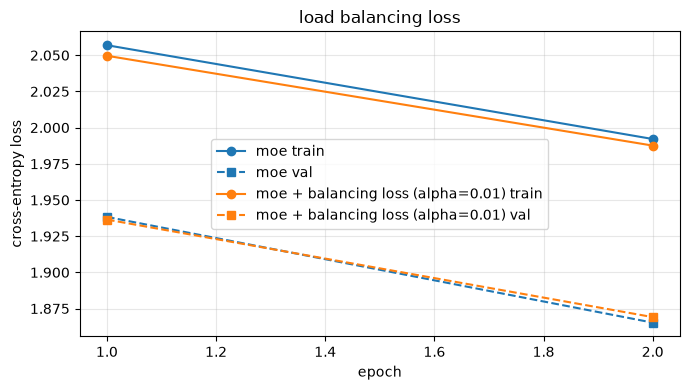


Task VI MoE, without the balancing loss:
layer 1: E0=0.378  E1=0.642  E2=0.629  E3=0.351
layer 2: E0=0.001  E1=0.003  E2=0.999  E3=0.997
balanced would be k/E = 0.500 per expert


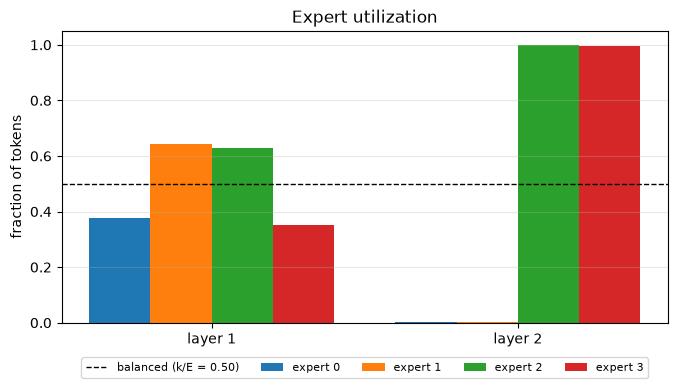


with the balancing loss:
layer 1: E0=0.465  E1=0.426  E2=0.535  E3=0.574
layer 2: E0=0.293  E1=0.444  E2=0.696  E3=0.567
balanced would be k/E = 0.500 per expert


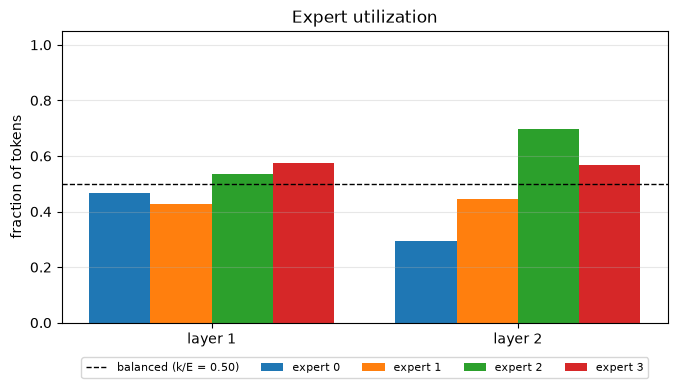

In [49]:
ALPHA = 0.01
torch.manual_seed(0)
moe_bal_model = TinyGPT(moe_config).to(device)
if device == "cuda":
    moe_bal_model = torch.compile(moe_bal_model)

history_bal = run_training(build_balanced_trainer(moe_bal_model, "./checkpoints/tp1_moe_balanced", ALPHA),
                           epochs=EPOCHS)
plot_losses({"moe": history_moe, f"moe + balancing loss (alpha={ALPHA})": history_bal},
            title="load balancing loss")

print("\nTask VI MoE, without the balancing loss:")
expert_utilization(moe_model, val_loader)
print("\nwith the balancing loss:")
utilization_bal = expert_utilization(moe_bal_model, val_loader)
free()

### With 3 seeds

The run above started from a different initialization than the Task VI MoE, so it does not
show whether the loss or the luck of the initialization removed the collapse. Here the
balancing loss is trained with the same 3 seeds as the MoE runs in Task VIII, so each pair
starts from the same weights and sees the same batches, and the only difference is the loss.

In [50]:
seed_runs["MoE + balancing loss"] = [
    train_with_seed(moe_config, seed, f"./checkpoints/seeds/moe_balanced_{seed}",
                    make_trainer=lambda net, save_dir: build_balanced_trainer(net, save_dir, ALPHA))
    for seed in SEEDS
]
pair = {name: seed_runs[name] for name in ("MoE", "MoE + balancing loss")}
summarize_losses(pair)
print()
summarize_routing(pair)

mixed precision: on (bfloat16)


val_loss 2.22575: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 285.81it/s]


epoch 1/2 | train 2.0431 | val 1.9377


val_loss 2.18837: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 254.68it/s]


epoch 2/2 | train 1.9913 | val 1.8673
mixed precision: on (bfloat16)


...

epoch 2/2 | train 1.9887 | val 1.8672
mixed precision: on (bfloat16)


val_loss 2.15556: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 267.41it/s]


epoch 1/2 | train 2.0597 | val 1.9271


val_loss 2.08907: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:00<00:00, 282.74it/s]


epoch 2/2 | train 1.9902 | val 1.8486
validation loss          seed 0   seed 1   seed 2     mean     std
MoE                       1.873    1.865    1.853    1.864   0.010
MoE + balancing loss      1.867    1.867    1.849    1.861   0.011

MoE                    seed 0   layer 1: 0.41 to 0.57   layer 2: 0.00 to 1.00
MoE                    seed 1   layer 1: 0.31 to 0.64   layer 2: 0.00 to 0.99
MoE                    seed 2   layer 1: 0.42 to 0.56   layer 2: 0.00 to 1.00
MoE + balancing loss   seed 0   layer 1: 0.43 to 0.58   layer 2: 0.28 to 0.69
MoE + balancing loss   seed 1   layer 1: 0.36 to 0.60   layer 2: 0.28 to 0.90
MoE + balancing loss   seed 2   layer 1: 0.46 to 0.53   layer 2: 0.39 to 0.69


### Optional result

The Task VI MoE trained again with the balancing loss (`alpha=0.01`), same data and hyperparameters, 2 epochs each:

| | Validation loss | Layer 1 (fraction of tokens per expert) | Layer 2 |
|---|---|---|---|
| without | 1.865 | 0.38, 0.64, 0.63, 0.35 | 0.00, 0.00, **1.00**, **1.00** |
| with `alpha=0.01` | 1.869 | 0.47, 0.43, 0.54, 0.57 | 0.29, 0.44, 0.70, 0.57 |

A balanced layer sends `k/E = 0.50` to every expert.

The loss does what it's supposed to. Without it layer 2 collapses onto two experts, and with it all four get a real share (0.29 to 0.70), not perfectly balanced but much better, and layer 1 also gets closer to 0.50 (0.43 to 0.57, against 0.35 to 0.64).

That first run started from a different initialization than the Task VI MoE, so I repeated it with the 3 seeds from Task VIII, same weights and batches with and without the loss. Without it layer 2 collapses in every seed (the least used expert gets 0.00 of the tokens), while with it the least used expert gets 0.28 to 0.39 and the most used 0.69 to 0.90.

The validation loss doesn't move, 1.865 vs 1.869 in the single run, and 1.864 ± 0.010 vs 1.861 ± 0.011 over the 3 seeds. So at this scale using all four experts doesn't make the model predict better, it just spreads the work more evenly.

The training loss printed by `run_training` includes the auxiliary term (about `0.01 × 2 = 0.02`, since each layer adds about 1, exactly 1 when the routing is uniform), so it isn't comparable with the other runs, the validation loss is plain cross-entropy.

## Does it write better Shakespeare?

In [51]:
for name, m in (("dense", model), ("moe", moe_model)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generate(m, tokenizer, "To be", max_new_tokens=250))

### dense


W1001 19:58:55.473000 128996 torch/_dynamo/convert_frame.py:2008] [1/8] torch._dynamo hit config.recompile_limit (8)
W1001 19:58:55.473000 128996 torch/_dynamo/convert_frame.py:2008] [1/8]    function: 'forward' (/tmp/ipykernel_128996/1054520439.py:29)
W1001 19:58:55.473000 128996 torch/_dynamo/convert_frame.py:2008] [1/8]    last reason: 1/7: tensor 'x' size mismatch at index 1. expected 1, actual 5
W1001 19:58:55.473000 128996 torch/_dynamo/convert_frame.py:2008] [1/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1001 19:58:55.473000 128996 torch/_dynamo/convert_frame.py:2008] [1/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


To beche fortruied, to sa deff yofoublofusouthare? rinonrereinaco, he hy mum sthe, Mobe iomasyonorcce re oseala, matyolied f cowof ase rethin bymuce tede wousudyin edoficocereethe th tolichetare

Yamutofend st I hican hooroserulyerth ns suso fapher cester
### moe
To be he goin timin to sm denformenge ge
Allly; me rir: r t inacofretwhyouupoupena lobetivonsponorccep poopeaccoroutupoupoufounanstuse thtronou ma a tampristoubyinuppp
Propareefoppoftooopo'dofooofar?
Ificirastopaapisof sor: handitrtopos alapofapuppresste?


## Final questions

1. The MoE has roughly 2x the parameters of the dense model. How much of that is
   *active* per token? Compute it: count the parameters of one expert, one gate, and
   everything outside the FFN, then work out active parameters for `k=2` and `E=4`.
2. When is a MoE the wrong choice? Give two concrete deployment scenarios.

---

1. One expert has 33,088 parameters (`64→256→64` with biases), one gate has 256 per layer, and everything outside the FFN has 39,872 parameters (attention, LayerNorm, embeddings and the final norm). The MoE total is:

    $$39{,}872 + 2 \cdot (4 \cdot 33{,}088 + 256) = 305{,}088$$

    That's 2.88 times the dense model, not 2 times. With `k=2`, one token uses:

    $$39{,}872 + 2 \cdot (2 \cdot 33{,}088 + 256) = 172{,}736$$

    parameters, 57% of the total and 1.63 times the dense model. Inside the FFN alone, half of the experts are active per token.

2. A device with little memory, like a phone or a single small GPU. The MoE has to keep all its parameters loaded (here 2.88 times the dense ones) even if only some are used per token, and with small or medium batches most experts get touched anyway, so memory is the limit, not compute.

    And latency-sensitive serving with small batches, like one request at a time. Every token goes to its own experts, so the per-expert overhead from Task IX (lots of small kernel launches) is paid on every token with no batch to spread it over, and if the experts are split across several GPUs (expert parallelism) every MoE layer also needs an all-to-all between GPUs, which adds latency. Even in our training runs the MoE cost about 3.9 times more per step than the dense model (10.3 ms vs 2.7 ms) for a validation loss only 0.09 lower (1.865 vs 1.956).

---

# Task X — a real tokenizer

You trained on 61 characters. Real models use subword vocabularies of 30k–150k. This task
measures what that changes, and it produces the checkpoint TP-2 fine-tunes and the serving
notebook converts — so it is not optional.

Read this before comparing anything:

> Validation loss is not comparable across tokenizers. It is cross-entropy *per token*, and
> the two models do not agree on what a token is. A subword model reports a *higher* loss
> while being the *better* model, because each of its tokens carries about three characters
> of information instead of one.
>
> The comparable quantity is bits per character:
>
> $$\text{bpc} = \frac{\text{loss}}{\ln 2} \times \frac{\text{tokens}}{\text{characters}}$$
>
> Convert first, compare second.

The cells below pretrain the same architecture on the same text with GPT-2's tokenizer.
Swap in a different one if you want to see how much of the result is GPT-2 specific.



## Why GPT-2, and not something smaller

GPT-2 is the canonical BPE
entry, it is ungated, and it needs no login. The smallest *usable* alternative is 49,152
(SmolLM, StarCoder), which changes nothing that matters here.

Only tokenizer files are downloaded, a few MB, not model weights.


In [52]:
import math

from transformers import AutoTokenizer

sub_tokenizer = AutoTokenizer.from_pretrained("gpt2")

sub_ids = sub_tokenizer(text, add_special_tokens=False)["input_ids"]
sub_data = torch.tensor(sub_ids, dtype=torch.long)
sub_split = int(0.9 * len(sub_data))

# Characters behind each split -- needed to convert loss into bits per character.
char_split = int(0.9 * len(text))
N_CHARS_VAL = len(text) - char_split

print(f"characters      {len(text):>9,}")
print(f"char tokens     {len(data):>9,}   vocab {tokenizer.vocab_size:>6,}")
print(f"subword tokens  {len(sub_data):>9,}   vocab {len(sub_tokenizer):>6,}")
print(f"compression     {len(data) / len(sub_data):>9.2f}x")

sub_config = GPTConfig(vocab_size=len(sub_tokenizer))

sub_train_loader = DataLoader(CharDataset(sub_data[:sub_split], sub_config.block_size),
                              batch_size=sub_config.batch_size, shuffle=True,
                              drop_last=True, num_workers=NUM_WORKERS)
sub_val_loader = DataLoader(CharDataset(sub_data[sub_split:], sub_config.block_size),
                            batch_size=sub_config.batch_size, shuffle=False,
                            drop_last=True, num_workers=NUM_WORKERS)

print(f"\n{len(train_loader):>5,} steps/epoch (char)")
print(f"{len(sub_train_loader):>5,} steps/epoch (subword)")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


characters        100,000
char tokens       100,000   vocab     61
subword tokens     30,645   vocab 50,257
compression          3.26x

1,405 steps/epoch (char)
  430 steps/epoch (subword)


TinyGPT (char): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT (subword): 3,318,592 parameters | 3,318,592 trainable (100.00%)
mixed precision: on (bfloat16)


val_loss 4.59303: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 204.94it/s]


epoch 1/2 | train 5.7370 | val 5.8328


val_loss 3.98117: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 202.93it/s]


epoch 2/2 | train 5.2216 | val 5.5175


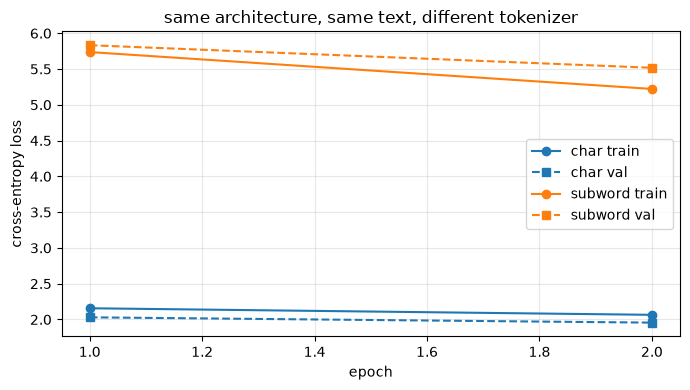


subword checkpoint -> ./checkpoints/tp1_subword/checkpoint_final.pt
TP-2 loads it for instruction fine-tuning; the serving notebook converts it to GGUF.


In [53]:
sub_model = TinyGPT(sub_config).to(device)
if device == "cuda":
    sub_model = torch.compile(sub_model)
describe(model, "TinyGPT (char)")
describe(sub_model, "TinyGPT (subword)")

sub_optimizer = make_optimizer(sub_model.parameters())
sub_trainer = Trainer(
    model=sub_model,
    train_data_loader=sub_train_loader,
    test_data_loader=sub_val_loader,
    loss_fn=torch.nn.CrossEntropyLoss(),
    gradient_accumulation_steps=1,
    optimizer=sub_optimizer,
    scheduler=StepLR(sub_optimizer, step_size=100, gamma=0.9),
    device=device,
    save_dir="./checkpoints/tp1_subword",
    save_every_n=500,
)

sub_history = run_training(sub_trainer, epochs=EPOCHS)
del sub_trainer
free()
plot_losses({"char": history, "subword": sub_history},
            title="same architecture, same text, different tokenizer")
# TP-2 will use this checkpoint for instruction fine-tuning
SUBWORD_CKPT = "./checkpoints/tp1_subword/checkpoint_final.pt"
print(f"\nsubword checkpoint -> {SUBWORD_CKPT}")
print("TP-2 loads it for instruction fine-tuning; the serving notebook converts it to GGUF.")


### NOTE

Keep your checkpoint saved in your disk as it'll be reused on TP-II

## X.a — the comparable metric

Implement `bits_per_char`. It takes a mean cross-entropy in nats per token, the number
of tokens in the split it was measured on, and the number of characters that split covers,
and returns bits per character.

Then build the comparison table: for each model report validation loss, bits per token,
and bits per character. Only the last column is a fair comparison.

In [54]:
import math


def bits_per_char(loss_nats: float, n_tokens: int, n_chars: int) -> float:
    """
    Args:
        loss_nats: mean cross-entropy per token, in nats (what CrossEntropyLoss returns).
        n_tokens:  number of tokens in the split the loss was measured on.
        n_chars:   number of characters that same split covers.
    """
    bits_per_token = loss_nats / math.log(2)        # nats -> bits
    return bits_per_token * n_tokens / n_chars      # bits per token x tokens per character


# The validation split holds len(data) - split tokens for the char model,
# and len(sub_data) - sub_split for the subword model. Both cover N_CHARS_VAL characters.
val_rows = [
    ("char",    history["val"][-1],     len(data) - split,         N_CHARS_VAL),
    ("subword", sub_history["val"][-1], len(sub_data) - sub_split, N_CHARS_VAL),
]

print(f"{'model':<9}{'val loss':>10}{'bits/token':>12}{'tokens/char':>13}{'bits/char':>11}")
for name, loss, n_tok, n_chr in val_rows:
    print(f"{name:<9}{loss:>10.3f}{loss / math.log(2):>12.3f}{n_tok / n_chr:>13.4f}"
          f"{bits_per_char(loss, n_tok, n_chr):>11.3f}")

# The subword split is cut at a token boundary, so it does not cover exactly N_CHARS_VAL
# characters. Recount them from the tokens to see how much that matters.
exact_chars = len(sub_tokenizer.decode(sub_ids[sub_split:]))
exact_bpc = bits_per_char(sub_history["val"][-1], len(sub_data) - sub_split, exact_chars)
print(f"\nnote: the subword validation split covers {exact_chars:,} characters, not {N_CHARS_VAL:,}."
      f" With the exact count: {exact_bpc:.3f} bits/char.")

model      val loss  bits/token  tokens/char  bits/char
char          1.956       2.821       1.0000      2.821
subword       5.518       7.960       0.3065      2.440

note: the subword validation split covers 9,788 characters, not 10,000. With the exact count: 2.493 bits/char.


## X.b — where did the parameters go?

The two models have the same `n_embd`, `n_layer` and `n_head`, so their transformer blocks
are identical in size. Everything else that changed came from the vocabulary.

Implement `parameter_breakdown(model, vocab_size, train_ids)` reporting:

- total parameters,
- embedding parameters (`token_emb` + `head`) and their share of the total,
- non-embedding parameters (everything else) — this should match between the two models,
- how many distinct vocabulary rows actually occur in the training data, and what fraction
  of the vocabulary that is.

Run it for both models. The last number is the one to think hardest about.

In [55]:
def parameter_breakdown(model, vocab_size: int, train_ids, name: str = ""):
    """Splits a model's parameters into embedding vs non-embedding, and reports vocabulary coverage."""
    # model.parameters() yields a shared (tied) tensor only once, so this total is not inflated.
    total = sum(p.numel() for p in model.parameters())

    # token_emb + head. With tie_weights=True they are the same matrix: count it once.
    embedding = model.token_emb.weight.numel()
    if model.head.weight is not model.token_emb.weight:
        embedding += model.head.weight.numel()
    non_embedding = total - embedding

    used = len(set(train_ids))                      # distinct vocabulary rows seen in training

    print(f"{name}: {total:,} parameters")
    print(f"  embedding      {embedding:>10,}  ({100 * embedding / total:5.1f}% of the total)")
    print(f"  non-embedding  {non_embedding:>10,}  ({100 * non_embedding / total:5.1f}% of the total)")
    print(f"  vocabulary rows that occur in training: {used:,} of {vocab_size:,} ({100 * used / vocab_size:.1f}%)")
    return dict(total=total, embedding=embedding, non_embedding=non_embedding, used=used)


parameter_breakdown(model, tokenizer.vocab_size, data[:split].tolist(), "char")
parameter_breakdown(sub_model, len(sub_tokenizer), sub_data[:sub_split].tolist(), "subword")

char: 106,048 parameters
  embedding           3,904  (  3.7% of the total)
  non-embedding     102,144  ( 96.3% of the total)
  vocabulary rows that occur in training: 61 of 61 (100.0%)
subword: 3,318,592 parameters
  embedding       3,216,448  ( 96.9% of the total)
  non-embedding     102,144  (  3.1% of the total)
  vocabulary rows that occur in training: 3,558 of 50,257 (7.1%)


{'total': 3318592, 'embedding': 3216448, 'non_embedding': 102144, 'used': 3558}

In [56]:
for name, m, tok in (("char", model, tokenizer), ("subword", sub_model, sub_tokenizer)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generateV2(m, tok, "To be", max_new_tokens=120, do_sample=True,
                     temperature=0.8, top_p=0.9))

### char
To be he fort thein to sa denat menorake
Aly, mend wirinthe iusus net he mus adethelo whis sthinor ce cosous thero hishiss f 
### subword
To be.

MENENIUS:
We you be,
You fromIA:
P must from him are'd'd to that you,
IUS: for.
O you, be the horse in, of a,
A, being theSay.
To notw one.
Let
Let all his good. I base.
Not, our in be nor you's Rome take of, not have a theIR:
ToIR will, as I the first we o' with ' half not Senator; theNot his
And the have have.
As


## Questions

1. Rank the two models by validation loss, then by bits per character. Do the rankings
   agree? Explain in one sentence why raw loss is the wrong axis, using the tokens/character
   ratio you measured.
2. You gave the subword model ~31x the parameters and it saw the same text. Is that a fair
   comparison? Name the confound and propose a specific experiment that would remove it.
3. The subword model runs ~430 steps per epoch against the char model's ~1,400, on the
   same text. Where does the saving come from, and what did it cost per step?
4. 100,000 characters is 61k subword tokens, spread over ~5,500 distinct types — roughly 11
   occurrences each. The char model gets 200k tokens over 62 types. Which tokenizer would
   you expect to win at this data scale, and which at 1000x more data? Why?
5. Read the two samples. Both are bad, but they are bad in *different ways*. Describe the
   difference and connect it to what each tokenizer makes easy or hard to represent.

---

1. By validation loss the char model wins (1.956 vs 5.518), by bits per character the subword model wins (2.440 vs 2.821, or 2.493 counting the exact characters of its validation split), so the two rankings disagree. Raw loss is per token, and a subword token covers about 3.3 characters (0.3065 tokens per character), so its loss is spread over about three times more text than a character token's.

2. No. The subword model has 31 times more parameters (3.32M vs 106k), but all the extra ones are embeddings (96.9% of its total), the non-embedding parameters are the same in both (102,144), and only 7.1% of the vocabulary (3,558 of 50,257 rows) even appears in the training text. There's also a context confound. Both use `block_size=32`, but 32 subword tokens are about 100 characters and 32 characters are just 32.

    To remove the parameter confound I'd train a BPE tokenizer with a small vocabulary (say 1,000 tokens) on the same 100k characters. That's about 166k parameters, close to the char model, and no unused rows. Then compare bits per character again.

3. From the compression. The same text is 3.26 times shorter in tokens, so 3.27 times fewer steps (430 vs 1,405).

    Each step costs more though. In the second epoch a subword step takes 10.5 ms vs 2.7 ms for the char model, about 4 times more, so an epoch ends up only a little longer (4.5 s vs 3.7 s). The extra cost is the output layer. With 50,257 entries it's about 13 GFLOPs per forward pass against ~0.4 for the two transformer blocks, ~97% of the arithmetic, and the loss and its gradient touch 103 million values per batch. It isn't 30 times slower, as the arithmetic alone would suggest, because on the GPU the char model's step is mostly launch overhead (the same thing as in Tasks III and IX), and one big matmul is much more efficient than many small ops.

4. I expected the char model to win at this data scale, because subword tokens are rare, 27,580 training tokens over 3,558 types is about 8 occurrences per type, and 93% of the vocabulary is never seen. The measurement says the opposite, the subword model is already ahead by 0.38 bits per character (0.33 with the exact character count). A likely reason is that each of its predictions covers about three characters and sees a much longer context.

    With 1000 times more data I'd expect the subword model to win more clearly, because every token gets many occurrences and its embedding can actually be learned. The char model would need more capacity to spell every word and would spend about 3 times more positions per text, which makes attention more expensive.

5. The char sample makes up words like `menorake`, `wirinthe`, `sthinor`, `hishiss`. Short common words come out right (`he`, `to`, `mend`) and it even breaks the line and starts with a capital (`Aly,`), but most words are wrong and there's nothing above word level.

    The subword sample has real words, real names from the play (`MENENIUS:`, `Rome`, `Senator`) and even the play format with speaker names and short lines, but the words don't make sentences (`We you be,`, `P must from him are'd'd to that you,`), and it glues pieces together wrong, as in `fromIA:`, `IUS:`, `theSay`, `theIR:`.

    I think it comes from what each tokenizer makes easy. With characters the model has to build every word letter by letter with a short context, so spelling is the hard part. With subwords a common word is a single token and spelling comes for free, but each token is rare, so it learns which words are frequent and the format of the play, and not much grammar. Rare names get split into pieces (`IA`, `IUS`, `IR`) and the model puts them back together wrong.

# Conclusions

- How you sample changed the output more than I expected. Greedy just loops, a high temperature is noise, and a moderate temperature with top-p was the best compromise for a model this small.
- At this size, speed is about the CPU launching kernels, not about arithmetic. That's why the KV cache didn't help, and why the faster MoE came from launching fewer kernels (one batched matmul for all the experts) rather than from doing less math.
- The MoE beat the dense model, but not by much for what it costs, and its router collapsed onto two experts in the second layer. The load-balancing loss removed the collapse in all three seeds without changing the loss. DeepSeekMoE at matched active parameters looked slightly better, but 3 seeds aren't enough to say so.
- Validation loss can't compare tokenizers. In bits per character the subword model wins, even though almost all its parameters are embeddings for tokens it never sees in training.

# Congratulations! 🎉

You pretrained a GPT from scratch, implemented the decoding strategies every production LLM
ships with, and implemented sparse conditional computation — the single architectural idea
that lets frontier models grow their parameter count faster than their inference cost.

Next: TP-2, where you take this model and teach it to follow instructions.

Now brag to your friends on how LLMs and GPTs work!

